# Coleta do Dataset ERA-5 e INMET




In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import time
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
import networkx as nx
from pyproj import Transformer
import torch
import matplotlib.pyplot as plt
import tqdm
from sklearn.metrics import r2_score
import os
import shutil
import torch.nn as nn
from torch_geometric.nn import GCNConv, ChebConv
import torch.nn.functional as F
import copy
from torch.utils.data import Dataset
from Dataset_Utils import station_dictionary, grafo_distancias, tensor_data, reset_weights, data_stations
torch.set_printoptions(threshold=100_000)
np.set_printoptions(threshold=np.inf)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
#rea    : dataset com dados de precipitação no RS
#rea_vv : dataset com dados de velocidade verticais em três valores de pressão
rea = xr.open_dataset(r'C:\Climate Change Project\Datasets\.nc files\era5_precipitation_80-26.nc')
rea_vv = xr.open_dataset(r"C:\Climate Change Project\Utils\vertical_velocity_data\era5_vv_06-25.nc")
catalogo_inmet = pd.read_csv(r'C:\Climate Change Project\Datasets\Dados INMET\CatalogoEstaçõesAutomáticas.csv', sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)
print("Dataset com "+str(rea.time.values.shape[0]/(2))+" dias")
N = 62

start_date = "2020-01-01"

Dataset com 16826.5 dias


In [3]:
rea_vv = rea_vv.sel(time=slice(start_date, None))

In [4]:
#TEMPO DE EXECUÇÃO APROXIMADO = 15min
#CRIA UM DATASET COM A MÉDIA DIARIA, MÁXIMO E MÍNIMO DA VELOCIDADE VERTICAL
def daily_vertical_velocity(ds, var_name, percentiles=[10]):
    da = ds[var_name]
    daily_mean = da.resample(time='1D').mean()
    print("Mean Done")
    daily_min = da.resample(time='1D').min()
    print("Min Done")
    daily_max = da.resample(time='1D').max()
    print("Max Done")
    q = [p/100 for p in percentiles]
    daily_percentiles = da.resample(time='1D').quantile(q)
    
    data_vars = {
        f'{var_name}_mean': daily_mean,
        f'{var_name}_min' : daily_min,
        f'{var_name}_max' : daily_max
    }
    
    for i, p in enumerate(percentiles):
        data_vars[f'{var_name}_p{p}'] = daily_percentiles.isel(quantile=i)
    
    return xr.Dataset(data_vars)



vv_dataset = daily_vertical_velocity(rea_vv,var_name='w')

Mean Done
Min Done
Max Done


In [4]:
pos = {}
i=0
coords = np.zeros((N,2))
for name in estacoes_RS.keys():
    pos[i] = float(estacoes_RS[name][1]), float(estacoes_RS[name][0])
    coords[i] = [float(estacoes_RS[name][1]), float(estacoes_RS[name][0])]
    i+=1

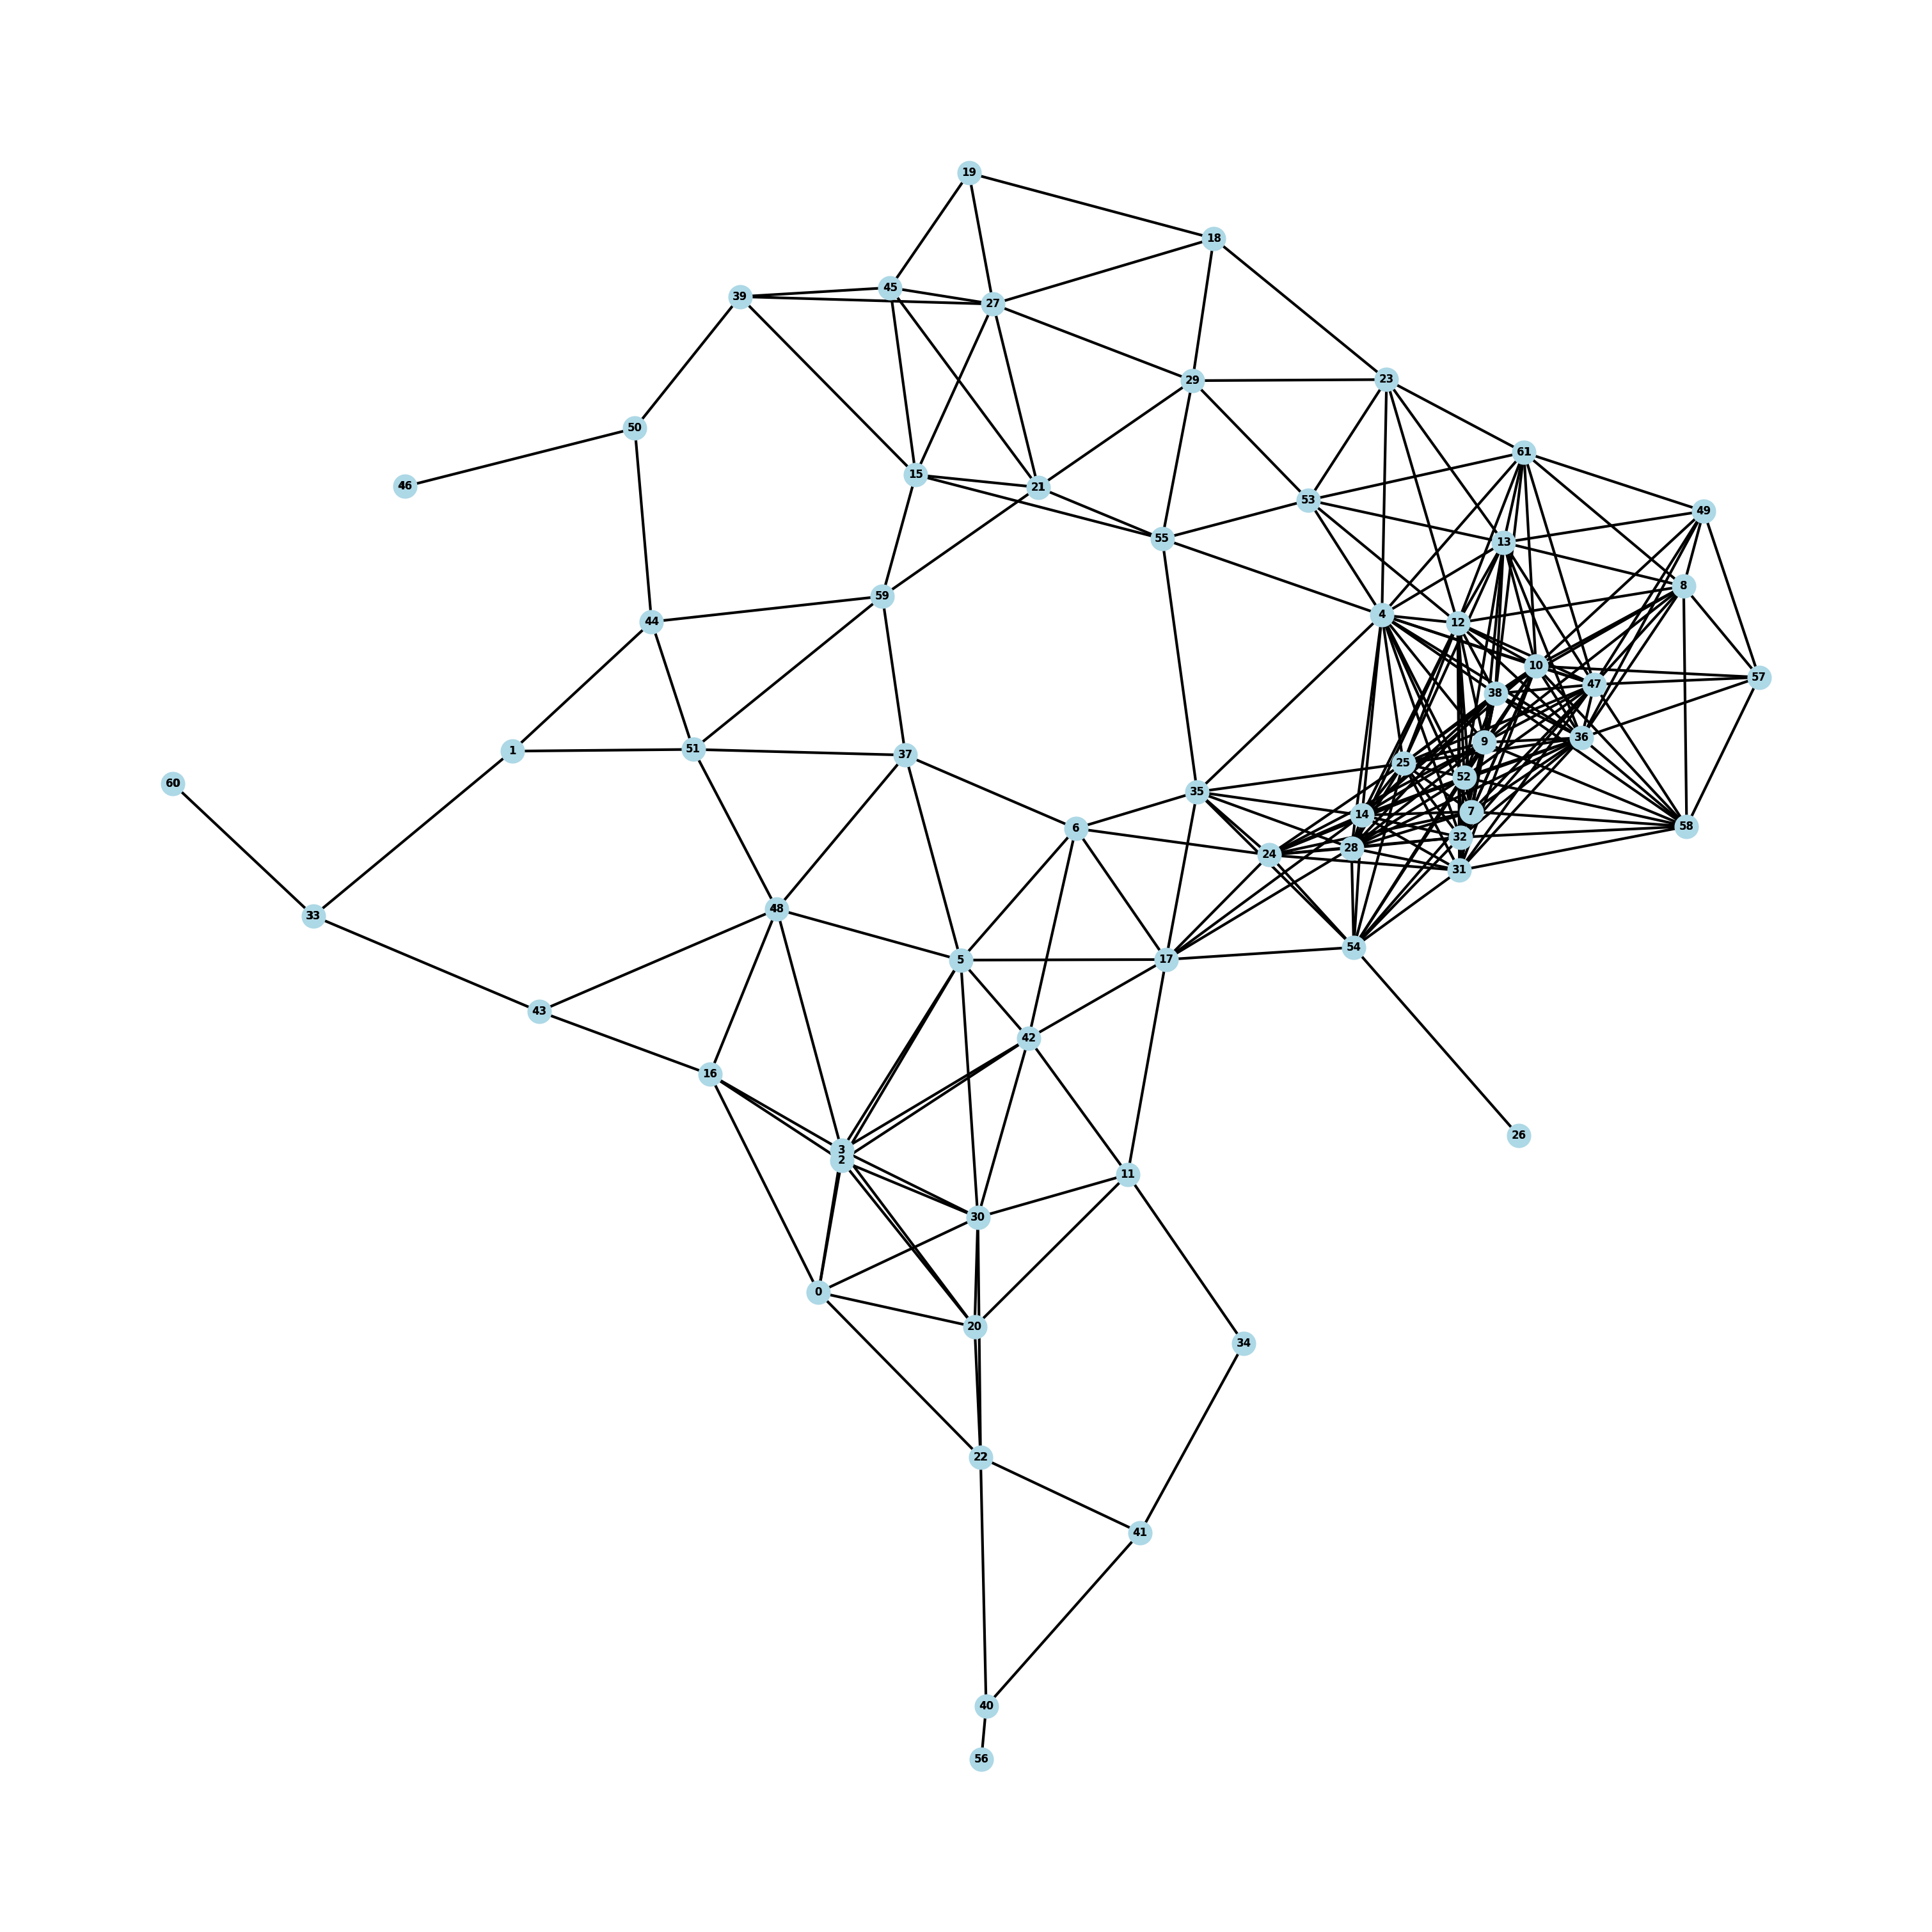

Construido grafo com  62 vértices


In [7]:
#cria a topologia dada pelas estações dentro de um criterio
import matplotlib.pyplot as plt

transformer = Transformer.from_crs("EPSG:4326", "EPSG:31982", always_xy=True)



edge_index, edge_weight = grafo_distancias(stations=estacoes_RS, criterion=115)
graph_data = Data(x=torch.zeros(62), edge_index=edge_index)



G = to_networkx(graph_data, to_undirected=True)

plt.figure(figsize=(30,30))
nx.draw(G,pos,
        with_labels=True,
        node_color='lightblue',
        node_size=700,
        width=3,
        font_weight='bold')



nx.draw_networkx_labels(G,pos,font_color='black')
plt.show()
print("Construido grafo com ",62,"vértices")



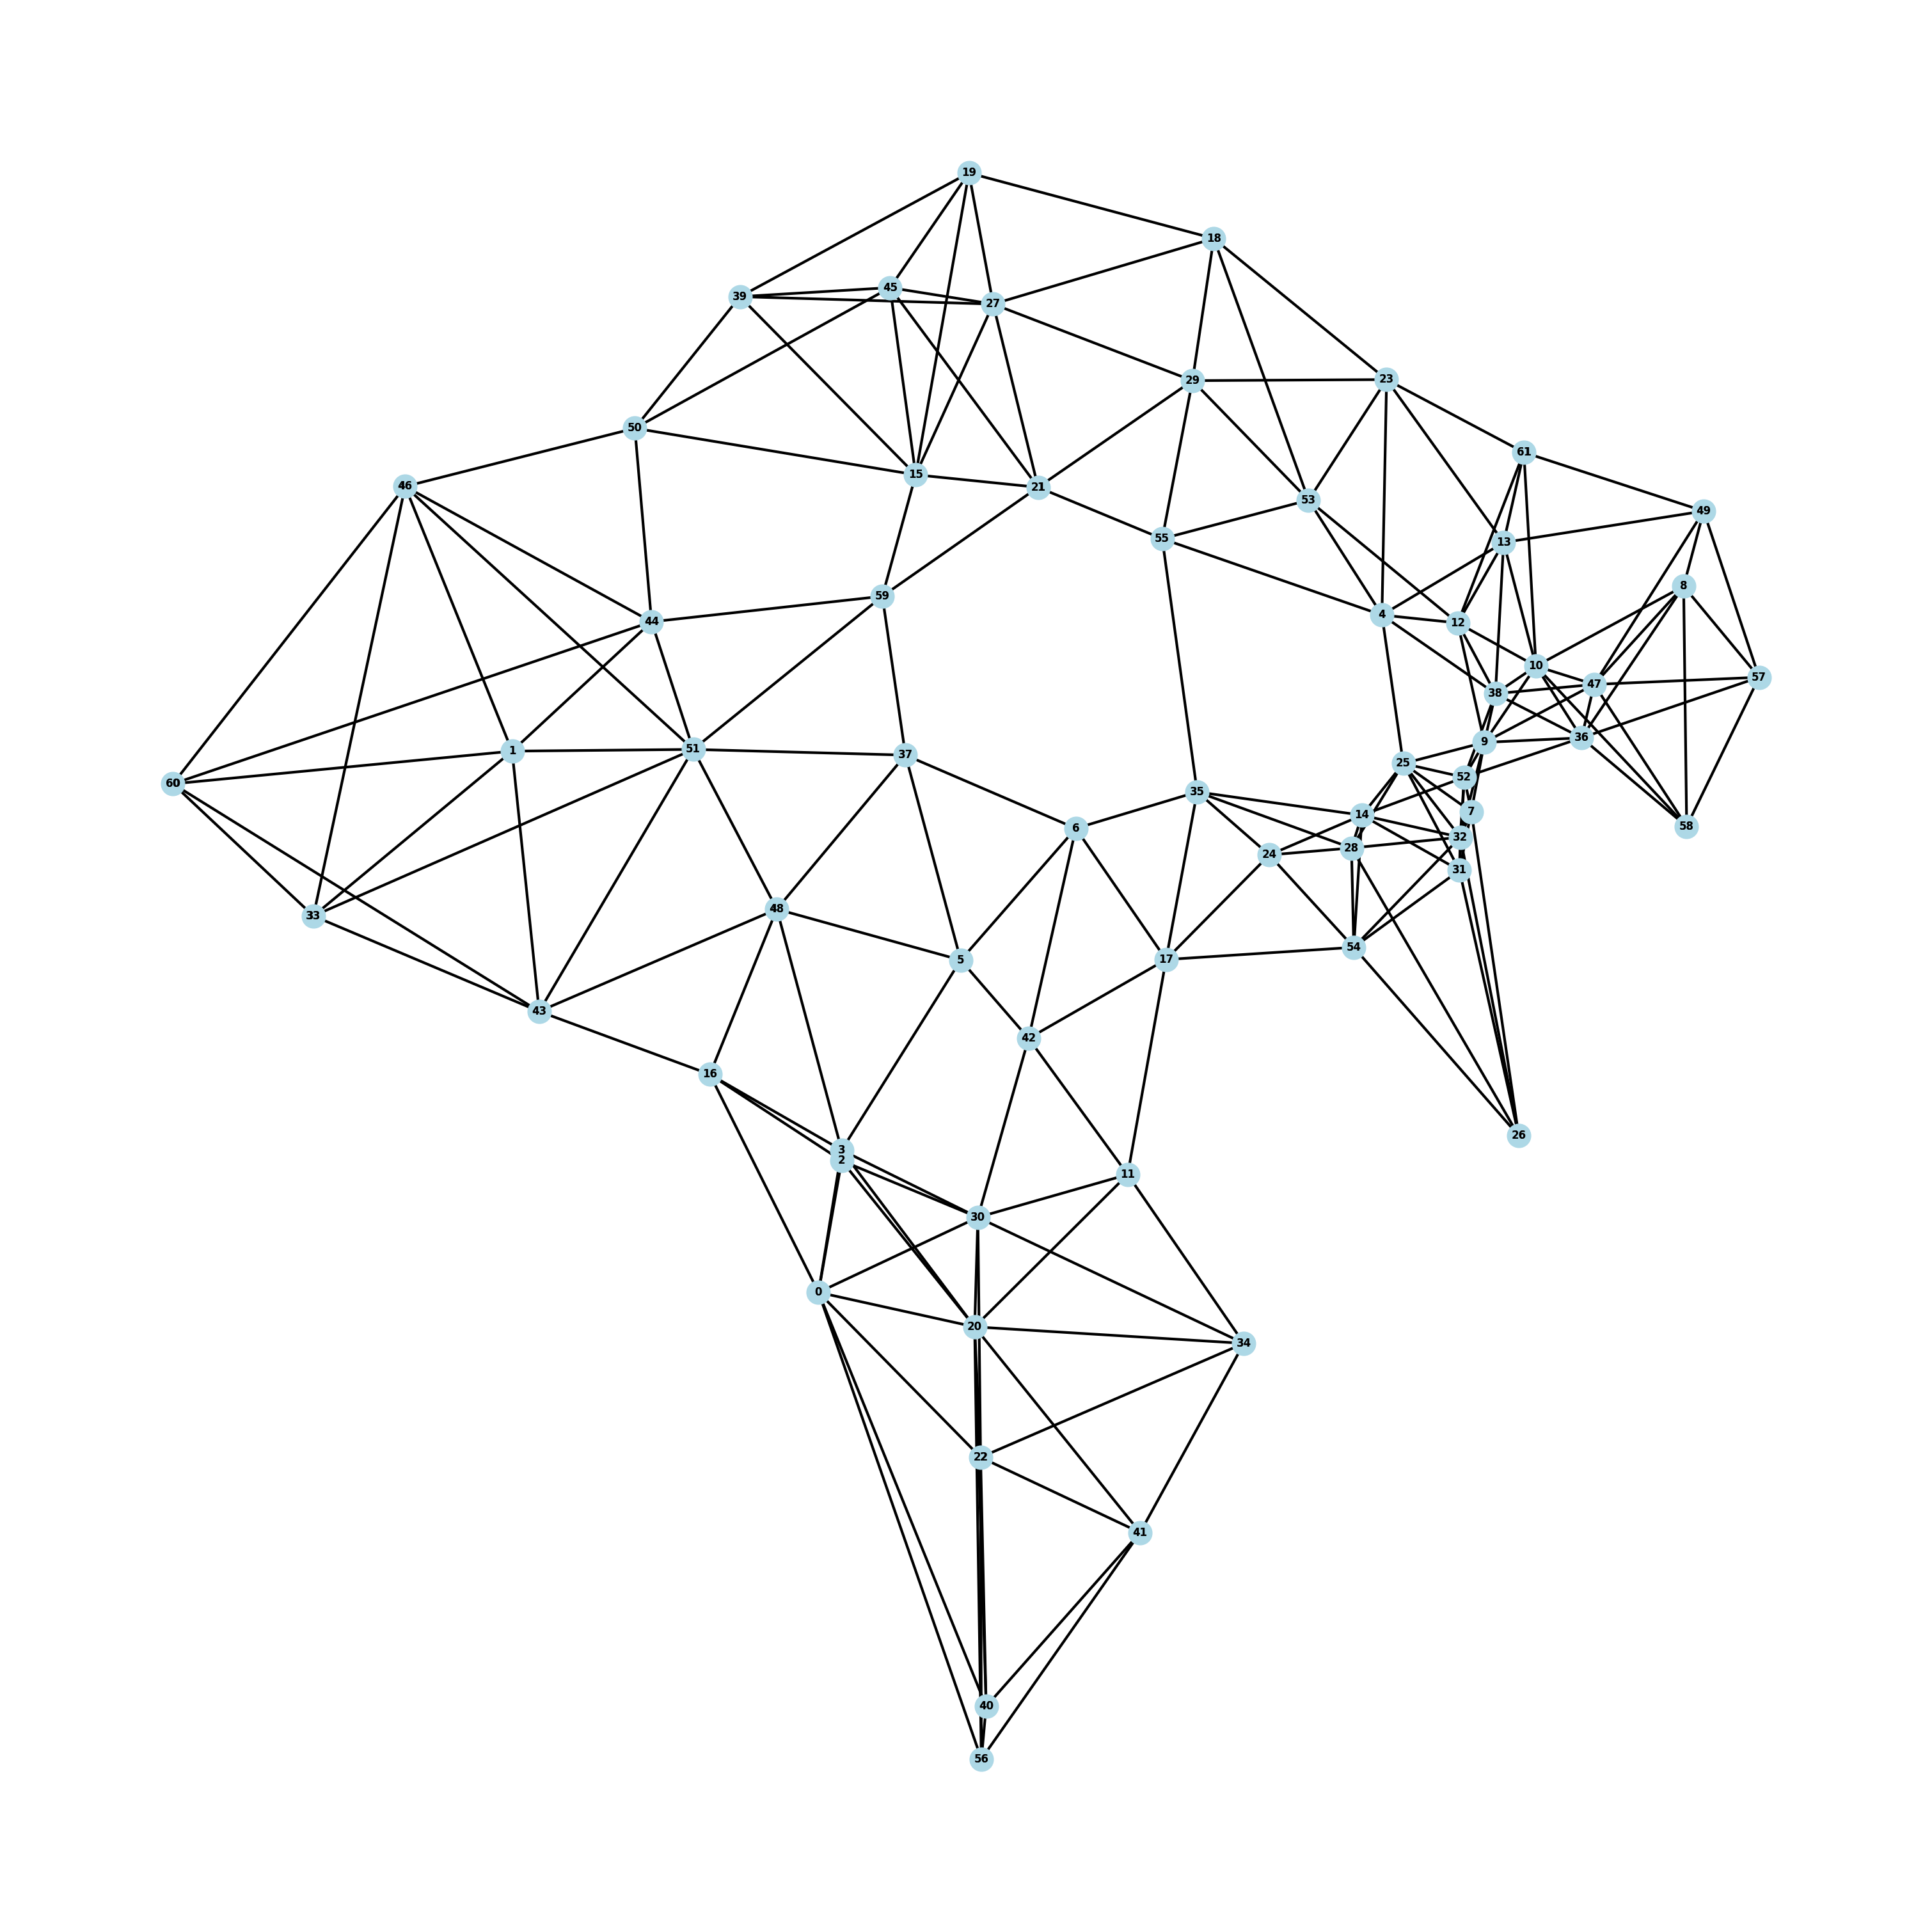

Construido grafo com  62 vértices


In [8]:
#cria a topologia usando knn
from sklearn.neighbors import NearestNeighbors

k = 5

nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
nbrs.fit(coords)

distances, indices = nbrs.kneighbors(coords)

E_1 = []
E_2 = []
for i in range(N):
    for j in indices[i][1:]:
        E_1.append(i)
        E_2.append(j)
        E_1.append(j)
        E_2.append(i)
edge_index_knn = torch.tensor([E_1,E_2],dtype=torch.int)



graph_data = Data(x=torch.zeros(62), edge_index=edge_index_knn)


G = to_networkx(graph_data, to_undirected=True)

plt.figure(figsize=(30,30))
nx.draw(G,pos,
        with_labels=True,
        node_color='lightblue',
        node_size=700,
        width=3,
        font_weight='bold')



nx.draw_networkx_labels(G,pos,font_color='black')
plt.show()
print("Construido grafo com ",N,"vértices")



In [ ]:
def get_vv(t1, t2, ds, stations):
    time_start = pd.to_datetime(t1)
    #time_end = pd.to_datetime(t2)
    N = len(stations)
    T = pd.to_datetime(t2)-pd.to_datetime(t1)
    T = T.days+1
    X = torch.zeros((T,N,4*3))
    i = 0
    da = ds.sel(time=slice(t1, t2))
    for station in stations.keys():
        start = time.time()
        lat, lon = stations[station][0], stations[station][1]
        da_sel = da.sel(latitude=lat, longitude=lon, method='nearest')
        X[:,i,0:3] = torch.tensor(da_sel.w_mean.values)
        
        if X.isnan().any():
            print("DADO NAN")
        i += 1
        #print("delta=", time.time()-start)
    return X

In [9]:
new_dataset = get_vv(t1="2020-01-01", t2="2025-12-31", ds=vv_dataset, stations=estacoes_RS)

print(new_dataset.shape)

torch.Size([2192, 62, 12])


In [10]:
def normalize_tp(tp, eps=1e-6):
    tp_log = torch.log1p(tp)
    mean = tp_log.mean()
    std = tp_log.std()
    return (tp_log-mean)/(std+eps), mean, std




In [11]:
end_date = "2025-12-31"
N = 62
t1 = pd.to_datetime(start_date)
t2 = pd.to_datetime(end_date)
T = t2-t1
T = T.days+1
#T = 10
print(T)

#Features de X: total precipitação, media7d, media14d, sazonalidade
X = torch.zeros((T,N,1+12+1))

print("Colhendo dados entre "+start_date+" e "+pd.to_datetime(end_date).strftime("%Y-%m-%d")+" ...") 


inicio = time.time()
X[:,:,13] = torch.tensor([[np.sin(np.pi*(t%365+1)/365) for _ in range(N)] for t in range(T)])
#X[:,:,0] = np.log1p(1000*tensor_data(t1, t2, rea, estacoes_RS).reshape(T+1,N))
X[:,:,0] = 1000*torch.tensor(tensor_data(t1, t2, rea, estacoes_RS)).reshape(T,N)
print("Step 1 Done, com "+str(time.time()-inicio)+" s")
X[:,:,1:13] = get_vv(t1=t1, t2=end_date, ds=vv_dataset, stations=estacoes_RS)
if X.isnan().any():
    print("Dataset com entradas NaN...")
    

print(X.shape)

2192
Colhendo dados entre 2020-01-01 e 2025-12-31 ...
Step 1 Done, com 432.53802394866943 s
torch.Size([2192, 62, 14])


C:\Users\bruno\AppData\Local\Temp\ipykernel_13796\1283424393.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X[:,:,0] = 1000*torch.tensor(tensor_data(t1, t2, rea, estacoes_RS)).reshape(T,N)


In [12]:
def day_index(start_date, index):
    real_date = pd.to_datetime(start_date)+pd.Timedelta(days=index)
    return real_date

In [28]:
def create_sliding_window(X, period):
    T = X.shape[0]
    Xs, ys = [], []
    for t in range(T-period):
        Xs.append(X[t:t+period-1])
        ys.append(X[t+period-1,:,0])
    return torch.stack(Xs), torch.stack(ys)

train_period = 7
Xs, ys = create_sliding_window(X, period=train_period)

Xs, ys = Xs.to(device), ys.to(device)

train_limit_index = Xs.shape[0]-30
val_limit_index = Xs.shape[0]-10



print(Xs.shape, ys.shape)

torch.Size([2185, 6, 62, 14]) torch.Size([2185, 62])


In [17]:
#DEPRECADO
#
#
def create_train_data(X, period):
    T = X.shape[0]
    Xs, ys = [], []
    for t in range(int(T/period)):
        Xs.append(X[t*period:t*period+period-1])
        ys.append(X[t*period+period-1])
    return torch.stack(Xs), torch.stack(ys)


#IMPLEMENTAR WINDOW DE PREVISÃO...
train_period = 30
Xs, ys = create_train_data(X, period=train_period)


train_limit_index = Xs.shape[0]-20
val_limit_index = Xs.shape[0]-15

print(Xs[:train_limit_index, :,:,0].shape, ys[:train_limit_index,:,:].shape)


Xs[:,:,:,0], ys = 1000*Xs[:,:,:,0], 1000*ys[:,:,:]

Xs_norm = torch.cat([Xs[:train_limit_index,:,:,0], ys[:train_limit_index,:,:].reshape(53,14,62)], dim=0)

#print(Xs_norm.shape)

#print(Xs[:,:,:,0].max())

var, mean, std = normalize_tp(Xs[:train_limit_index,:,:,0])

Xs[:train_limit_index, :,:,0] = var
ys = (np.log1p(ys)-mean)/std

torch.Size([53, 29, 62]) torch.Size([53, 62, 14])


RuntimeError: Sizes of tensors must match except in dimension 0. Expected size 29 but got size 14 for tensor number 1 in the list.

# Modelo de GNN com LSTM



In [29]:
import random

def adjacency_matrix(N, edge_index, edge_weight=None):
    A = torch.zeros((N,N))
    for i in range(0,len(edge_index[0]),2):
        u, v = edge_index[0][i], edge_index[0][i+1]
        A[u,v] = edge_weight[i]
        A[v,u] = edge_weight[i]
    return A


#print(adjacency_matrix(N, edge_index, edge_weight=edge_weight)[0])

In [32]:

from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F
from torch_geometric.nn.conv import GCNConv, ChebConv


#CELULA DE GLSTM DESCRITA NO ARTIGO, POR ITERAÇÃO DE TEMPO RECEBE UM TENSOR X (feature, N) E OS ESTADOS OCULTOS H_prev E C_prev DA GLSTM DO TEMPO ANTERIOR
class GLSTMCell(nn.Module):
    def __init__(self, N, input_size, hidden_size, edge_index, edge_weight=None, learn_adj=True):
        super().__init__()
        self.learn_adj = learn_adj
        
        if edge_weight == None:
            self.edge_weight = nn.Parameter(torch.ones(edge_index.shape[1]))
        else:
            self.edge_weight = nn.Parameter(edge_weight)
        
        if learn_adj:
            self.A = nn.Parameter(adjacency_matrix(N, edge_index, self.edge_weight))
        else:
            self.gcn_h = GCNConv(hidden_size, hidden_size)
            self.gcn_c = GCNConv(hidden_size, hidden_size)
            
        
        #self.chebconv = ChebConv(hidden_size, hidden_size, K=2)
        self.hidden_size = hidden_size
        self.edge_index = edge_index
        #self.adj_matrix = nn.Parameter(adjacency_matrix(N, edge_index))
        #self.adj = nn.Parameter(adj_matrix).to(device)
        
        
            
            
        #MATRIZES DOS GATES DE INPUT, FORGET, OUTPUT E CELL-UPDATE QUE TRANSFORMA X
        self.W_i = nn.Linear(input_size, hidden_size)
        self.W_f = nn.Linear(input_size, hidden_size)
        self.W_o = nn.Linear(input_size, hidden_size)
        self.W_u = nn.Linear(input_size, hidden_size)
        
        
        #MATRIZES DOS GATES DE INPUT, FORGET, OUTPUT E CELL-UPDATE QUE TRANSFORMAM H_prev E H_prev*ADJACENCIA
        self.U_i = nn.Linear(hidden_size, hidden_size)
        self.U_f = nn.Linear(hidden_size, hidden_size)
        self.U_o = nn.Linear(hidden_size, hidden_size)
        self.U_u = nn.Linear(hidden_size, hidden_size)
    
        
    def forward(self, X, H_prev, C_prev):
        
        #X             : (input_size, N)
        #h_prev/c_prev : (hidden_size, N)
        
        

        
        #I, F, O, U : (hidden_size, N)
        #H_graph = torch.matmul(H_prev, self.adj)
        #C_graph = torch.matmul(C_prev, self.adj)
        #print("Antes", H_prev.shape)
        
        
        if self.learn_adj == False:
            H_graph = self.gcn_h(H_prev.T, self.edge_index)
            H_graph = H_graph.relu()
            H_graph = self.gcn_h(H_graph, self.edge_index).T
            
            
            C_graph = self.gcn_c(C_prev.T, self.edge_index)
            C_graph = C_graph.relu()
            C_graph = self.gcn_c(C_graph, self.edge_index).T
        
        else:
            H_graph = torch.matmul(self.A,H_prev.T).T
            #H_graph = H_graph.relu()
            
            C_graph = torch.matmul(self.A, C_prev.T).T
            #C_graph = C_graph.relu()
        
        I = torch.sigmoid(self.W_i(X)+self.U_i(H_graph.T)).T
        F = torch.sigmoid(self.W_f(X)+self.U_f(H_prev.T)).T
        O = torch.sigmoid(self.W_o(X)+self.U_o(H_graph.T)).T
        U = torch.tanh(self.W_u(X)+self.U_u(H_graph.T)).T
        
        #print(I.shape, F.shape, O.shape, U.shape)
        
        C_t = I*U + F*C_graph # (hidden_size, N)
        H_t = O*torch.tanh(C_t)


        return C_t, H_t #ambos de dimensão (hidden_size, N)
    
    
    
class GLSTM(nn.Module):
    def __init__(self, N, edge_index, in_channels, hidden_size, num_layers=1, out_channels=1, learn_adj=True, edge_weight=None):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.N = N
        self.edge_index = edge_index
        
        if edge_weight == None:
            self.edge_weight = nn.Parameter(torch.ones(edge_index.shape[1]))
        else:
            self.edge_weight = nn.Parameter(edge_weight)
        
        #self.adj_matrix = nn.Parameter(adjacency_matrix(self.N, edge_index))
        self.cells = nn.ModuleList([GLSTMCell(N=N, input_size=in_channels, hidden_size=hidden_size, edge_index=self.edge_index, edge_weight=self.edge_weight, learn_adj=learn_adj) for _ in range(num_layers)])
        
        self.fc = nn.Sequential(
            nn.Linear(self.hidden_size, hidden_size//2),
            nn.LeakyReLU(negative_slope=0.03),
            nn.Dropout(0.2),
            nn.Linear(self.hidden_size//2, out_channels),
            nn.Softplus()
        )
        
    def forward(self, x_seq):
        
        #x_seq : (T,N,F)
        
        #F = in_channels
        
        T, N, _ = x_seq.shape
        H, C = torch.zeros((self.hidden_size,self.N), device=x_seq.device), torch.zeros((self.hidden_size, self.N), device=x_seq.device)
        
        #H = [torch.zeros(self.hidden_size,N, device=x_seq.device) for _ in range(self.num_layers)]
        #C = [torch.zeros(self.hidden_size,N, device=x_seq.device) for _ in range(self.num_layers)] #praticamente é sempre utilizado num_layers=1 (nem implementei multiplos layers de GLSTMCells...)
        
        outputs = []
        
        #IMPLEMENTAR NUMERO DE LAYERS MAIOR
        for t in range(T-1):
            #print("Step t=", t)
            H, C = self.cells[0](x_seq[t], H,C)
            # H, C : (hidden_size, N)
            #outputs.append(H)
        
        out, _ = self.cells[0](x_seq[t], H, C)
        
        #outputs = torch.stack(outputs, dim=0) #(T, N, hidden_size)
        
        #out = outputs[-1,:,:]
        
        out = out.T
        
        
        #print("saida do modelo com dimensão = ", out.shape)
        #print(self.fc(out).shape)
        return self.fc(out)

Training period = 2020-01-01 to 2025-12-31


 28%|██▊       | 28/100 [12:07<27:46, 23.15s/it]

Early Stopping...


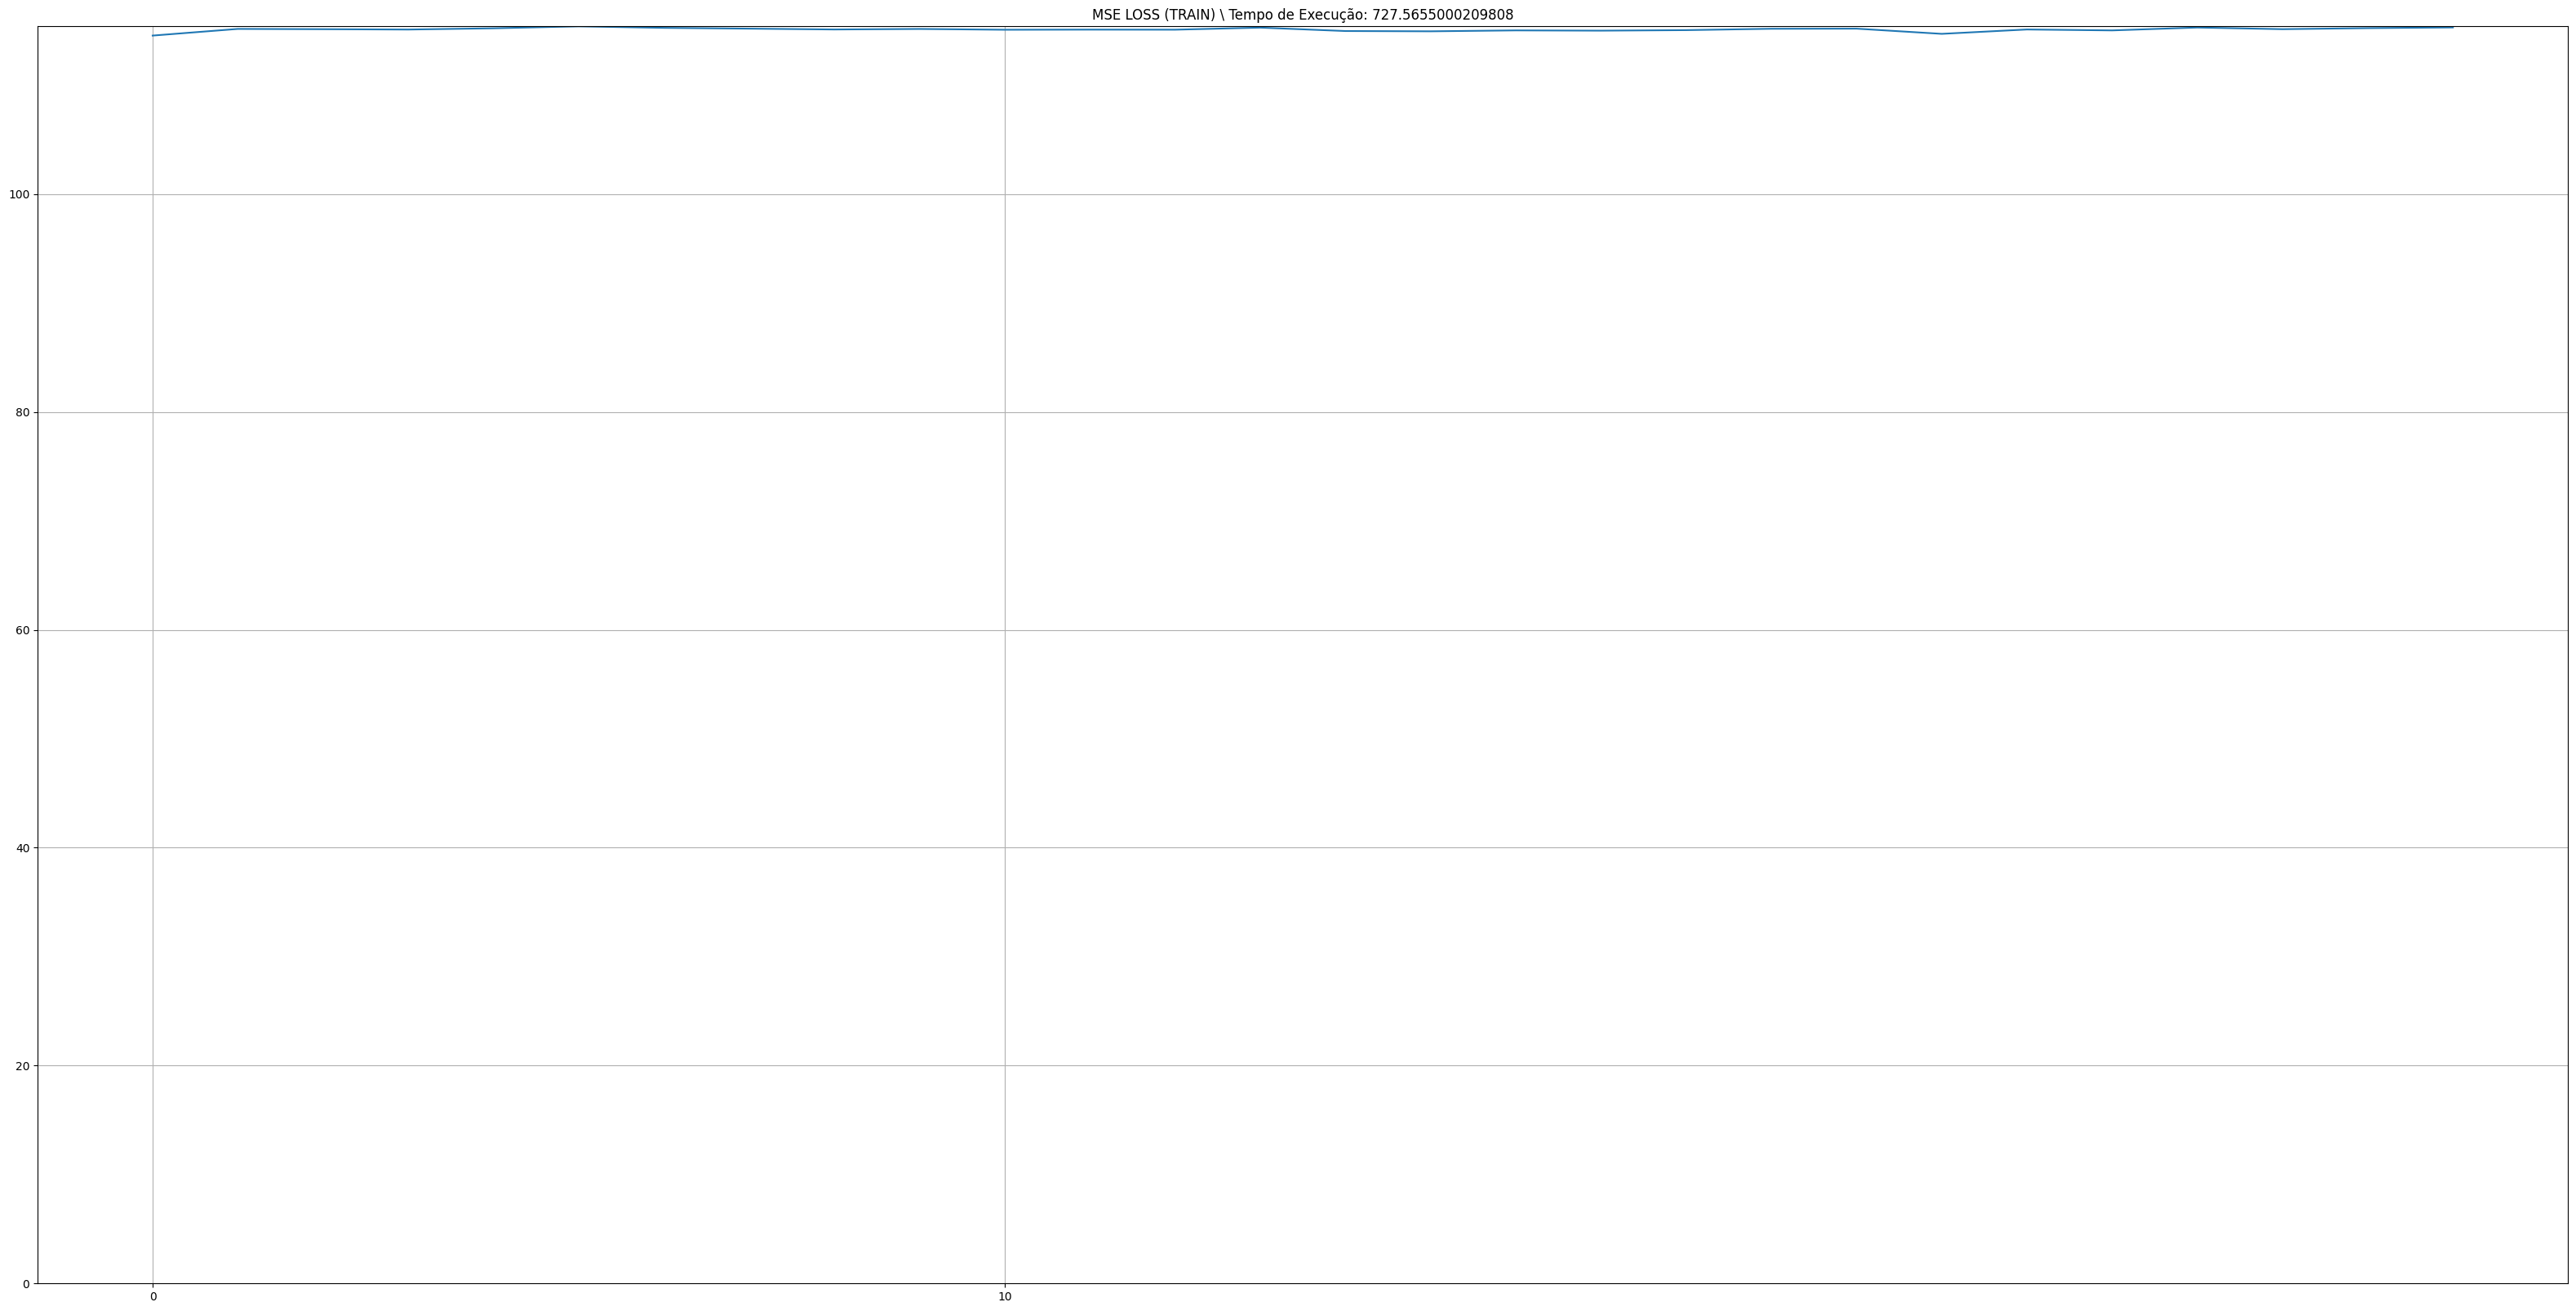

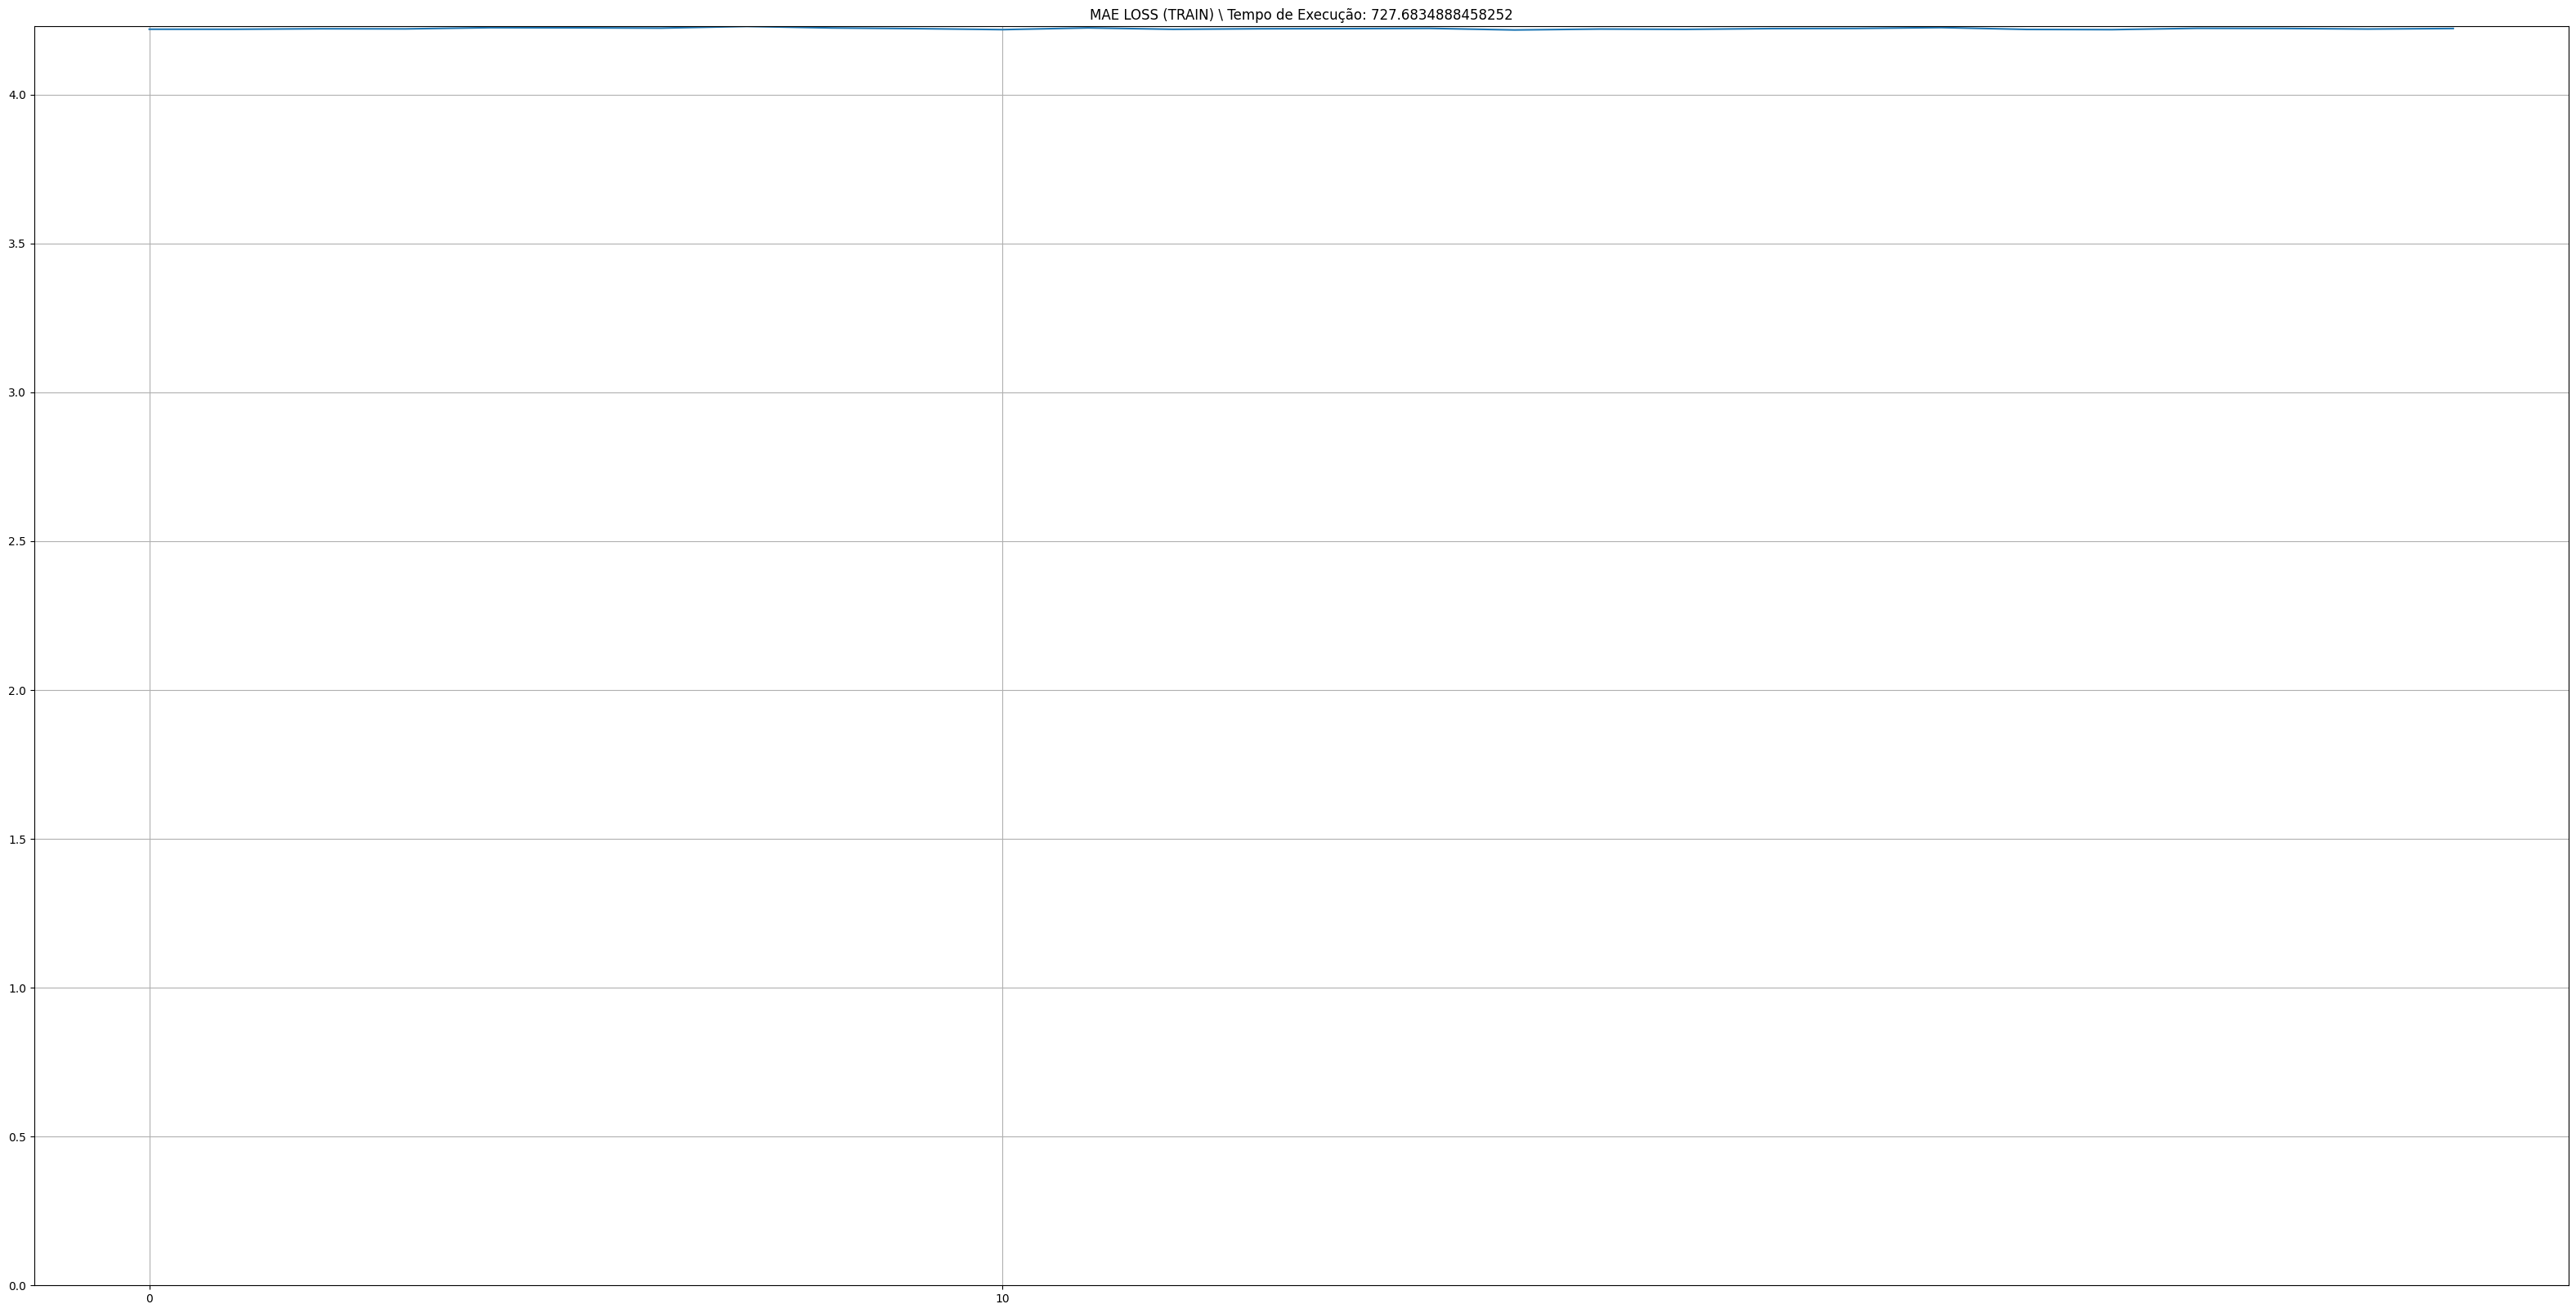

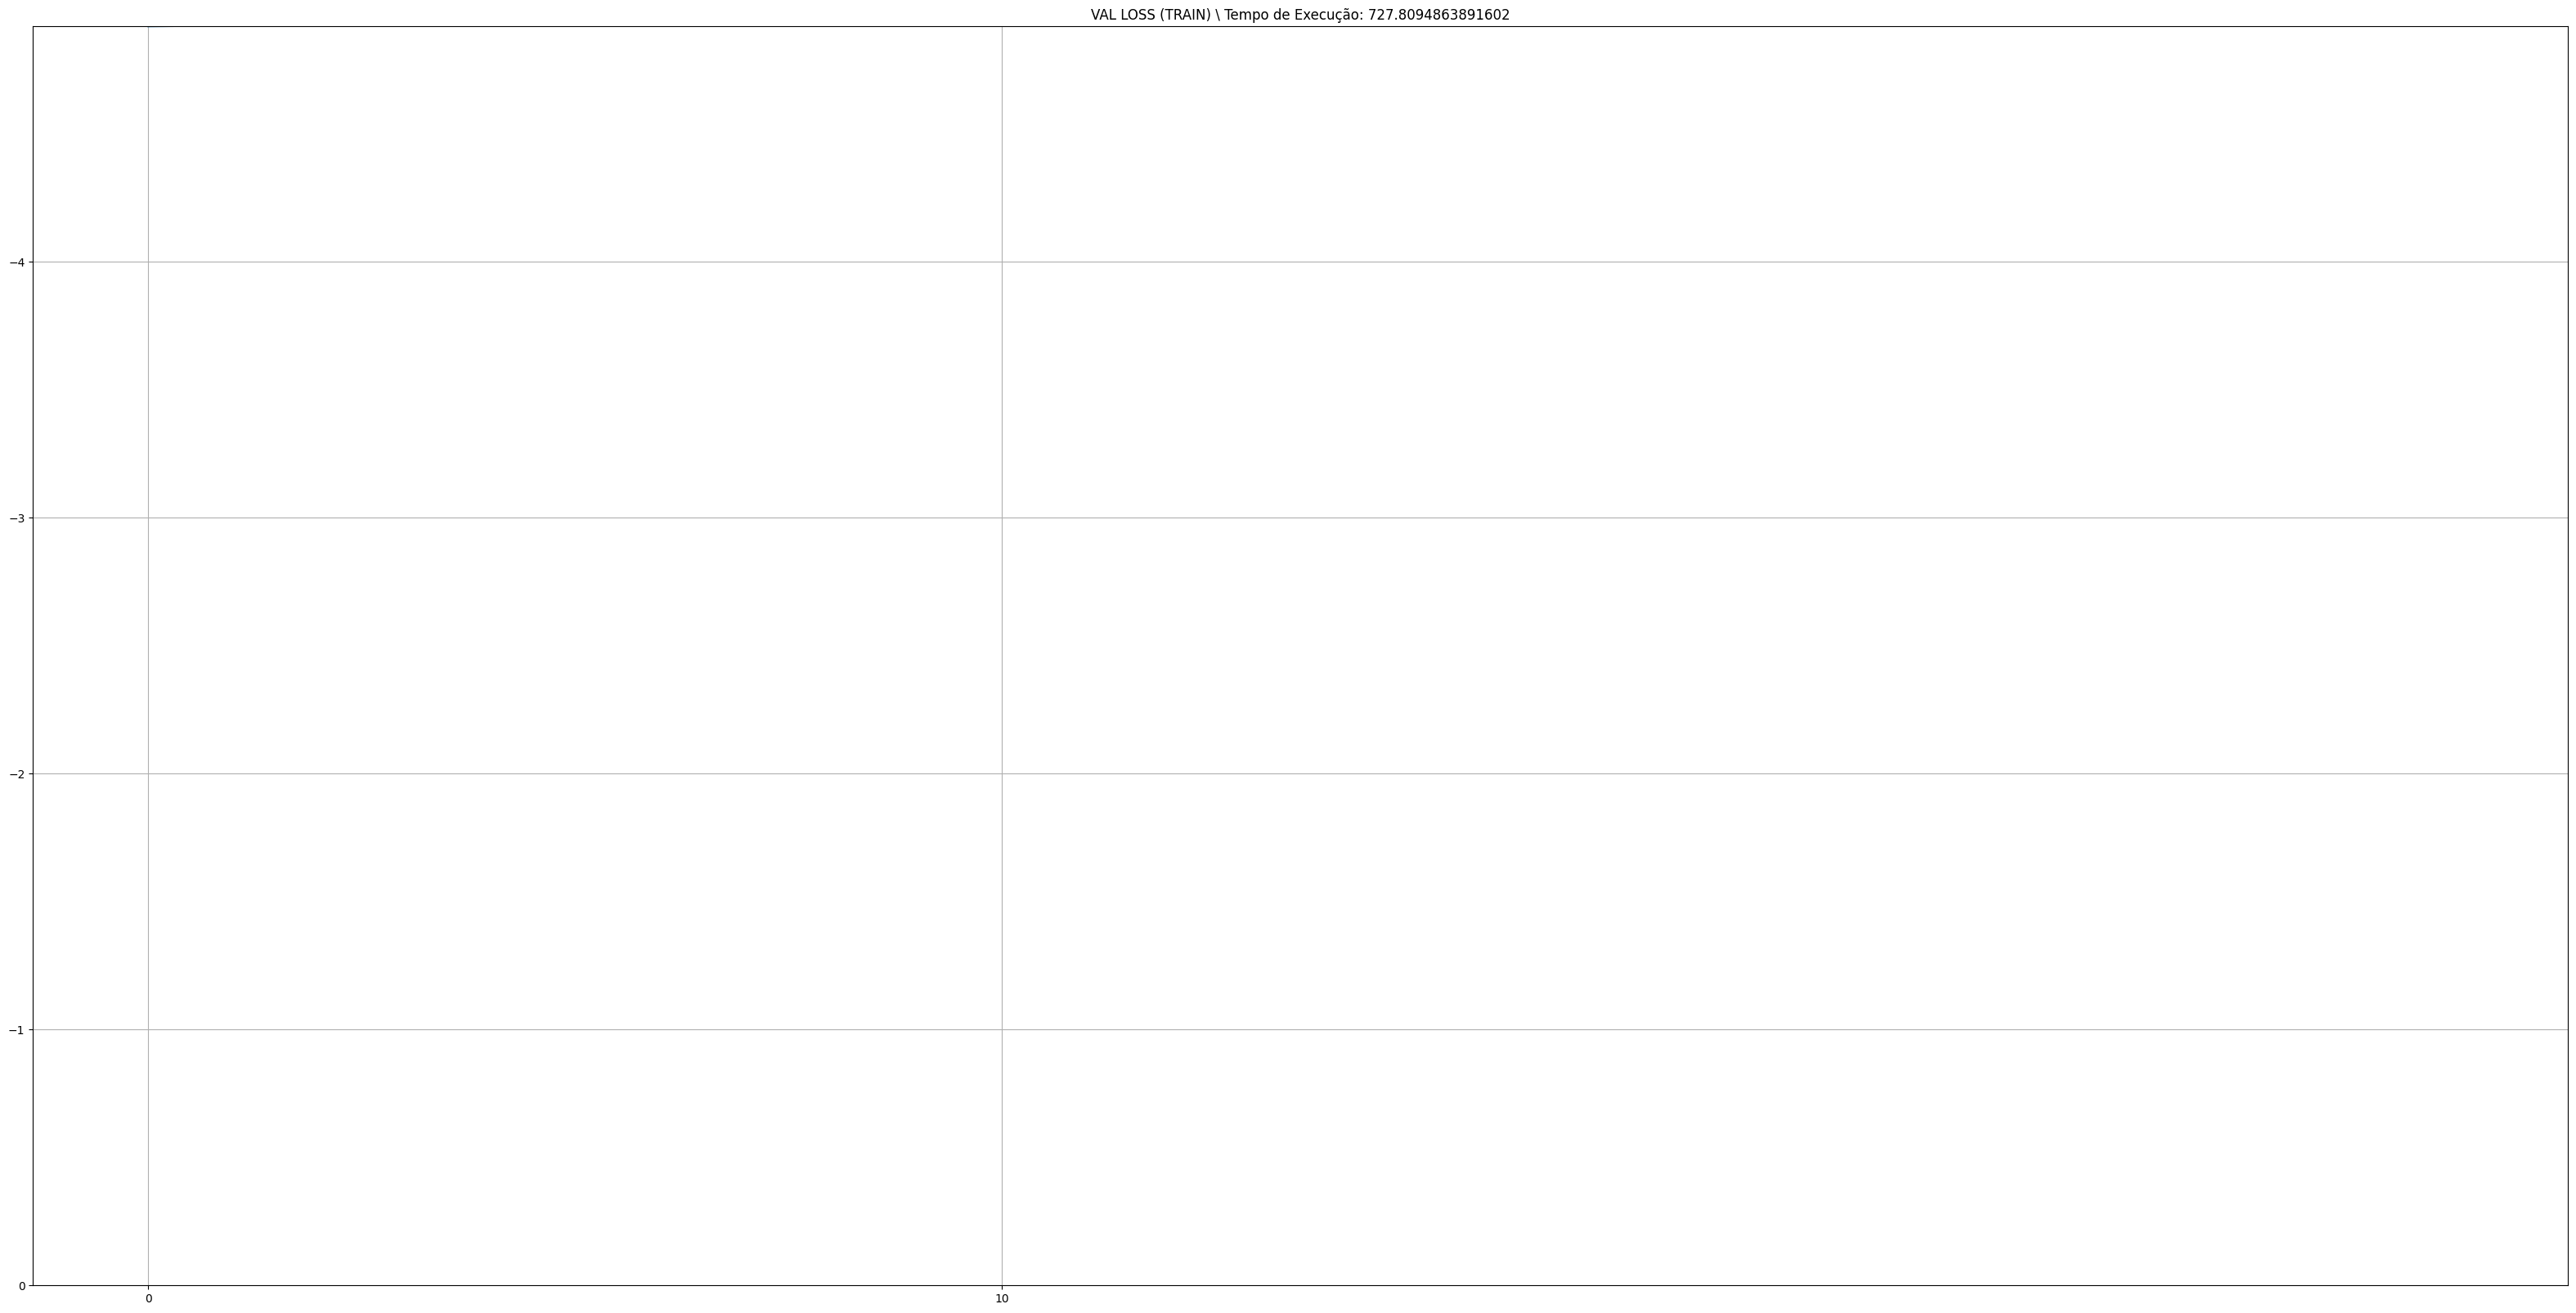

In [41]:
#SINGLE EXECUTION
# PASTA MASTER: path_folder
#SALVAR AS LOSSES FINAIS (TREINO, VALIDAÇÃO, TESTE) PARA COMPARAÇÃO

test_counter = 0
path_folder = r"C:\Testes_GNN_LSTM\14_02"

if os.path.exists(path_folder)==False:
    os.mkdir(path_folder)

path = path_folder+f"\\Test_{test_counter}"
if os.path.exists(path)==False:
    os.mkdir(path)


topology = 'distance'
N = 62
patience = 10
val_error = 0
epochs = 100
lr = 1e-2
weight_decay = 5e-4
hidden_dim = 32
num_layers = 1



MAE = nn.L1Loss()
MSE = nn.MSELoss()
loss_fn = nn.L1Loss()

T_train = train_limit_index
T_val = val_limit_index-train_limit_index

print("Training period = "+str(start_date)+" to "+str(end_date))


edges = edge_index.to(device) if topology=='distance' else edge_index_knn.to(device)

A = adjacency_matrix(N, edges, edge_weight)

model = GLSTM(N=N, edge_index=edges, in_channels=14, hidden_size=hidden_dim, num_layers=1, out_channels=1).to(device)
model.apply(reset_weights)
optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=weight_decay)

for p in model.parameters():
    p.requires_grad = True


best_model = model.state_dict()
best_val_loss = float('inf')
#val_loss = 0
counter = 0




train_loss = []
train_mse = []
train_mae = []
train_r2 = []

val_loss = []
val_mse = []
val_mae = []
val_r2 = []





epoch_pbar = tqdm.tqdm(total=epochs, leave=False)
tempo_inicio = time.time()
for epoch in range(epochs):
    #all_preds_val, all_val = [], []
    #all_preds_train, all_train = [], []

    
    model.train()
    train_loss_counter, train_mse_counter, train_mae_counter, train_r2_counter = 0, 0, 0, 0
    
    pbar = tqdm.tqdm(total=T_train, leave=False)
    for t in range(T_train):
        
        X_train = Xs[t]
        y_train = ys[t]
        optimizer.zero_grad()
        y_pred = model(X_train)
        
        loss = loss_fn(y_pred.reshape(N), y_train.reshape(N))
        loss.backward()
        optimizer.step()
        
      
        
        
        train_mse_counter += MSE(y_pred.detach().reshape(N), y_train.reshape(N))
        train_mae_counter += MAE(y_pred.detach().reshape(N), y_train.reshape(N))
       
        train_loss_counter += loss.item()
        pbar.update(1)
    pbar.close()
    train_mse_counter /= T_train
    train_loss_counter /= T_train
    train_mae_counter /= T_train
    train_loss.append(train_loss_counter)
    train_mse.append(train_mse_counter)
    train_r2.append(train_r2_counter)
    train_mae.append(train_mae_counter)
    model.eval()
    
    val_loss_counter, val_mse_counter, val_mae_counter = 0, 0, 0
    with torch.no_grad():
        for t in range(train_limit_index, val_limit_index):
            X_val = Xs[t]
            y_val = ys[t]
            y_pred = model(X_val)
            loss = loss_fn(y_pred.reshape(N), y_val.reshape(N))
            
            val_mse_counter += MSE(y_pred.reshape(N),y_val.reshape(N)).item()
            val_mae_counter += MAE(y_pred.reshape(N),y_val.reshape(N)).item()
            val_loss_counter += loss.item()
        
        val_mse_counter /= train_limit_index-val_limit_index
        val_mae_counter /= train_limit_index-val_limit_index
        val_loss_counter /= train_limit_index-val_limit_index
        
                    
        val_loss.append(val_loss_counter)
        val_mse.append(val_mse_counter)
        val_mae.append(val_mae_counter)
        #val_r2.append(r2_score(y_val.reshape(N).cpu(), y_pred.reshape(N).cpu()))
        #val_loss_count += loss.item()
    epoch_pbar.update(1)
    if val_loss_counter<best_val_loss:
        best_val_loss = val_loss_counter
        counter = 0
        best_model = copy.deepcopy(model.state_dict())
        
    else:
        counter+=1
    
    if counter>patience:
        model.load_state_dict(best_model)
        print("Early Stopping...")
        break
    
plt.figure(figsize=(40,20))
plt.plot(torch.tensor(train_mse).cpu())
plt.ylim(0,torch.tensor(train_mse).max())
plt.grid(True)
plt.xticks([10*t for t in range(int(len(train_mse)/10))])
plt.title("MSE LOSS (TRAIN) \\ Tempo de Execução: "+str(time.time()-tempo_inicio))
plt.savefig(path+r"\\MSE_LOSS_TRAIN.svg", format="svg")
plt.show()

plt.figure(figsize=(40,20))
plt.plot(torch.tensor(train_mae).cpu())
plt.ylim(0,torch.tensor(train_mae).max())
plt.grid(True)
plt.xticks([10*t for t in range(int(len(train_mae)/10))])
plt.title("MAE LOSS (TRAIN) \\ Tempo de Execução: "+str(time.time()-tempo_inicio))
plt.savefig(path+r"\\MAE_LOSS_TRAIN.svg", format="svg")
plt.show()

plt.figure(figsize=(40,20))
plt.plot(torch.tensor(val_loss).cpu())
plt.ylim(0,torch.tensor(val_loss).max())
plt.grid(True)
plt.xticks([10*t for t in range(int(len(val_loss)/10))])
plt.title("VAL LOSS (TRAIN) \\ Tempo de Execução: "+str(time.time()-tempo_inicio))
plt.savefig(path+r"\\MAPE_LOSS_TRAIN.svg", format="svg")
plt.show()

hiper_log =" epochs:"+str(epochs)+"\n hidden_dim:"+str(hidden_dim)+"\n patience:"+str(patience)+"\n weight_decay:"+str(weight_decay)+"\n lr:"+str(lr)+"\n Loss:"+str(loss_fn)+"\n topology:"+topology

torch.save(train_mse,path+r"\train_mse.pt")
torch.save(train_mae,path+r"\train_mae.pt")
torch.save(val_loss,path+r"\val_error.pt")

with open(path+r"\log_hiper_parametros.txt", "w") as file:
    file.write(hiper_log)
epoch_pbar.close()
test_counter += 1

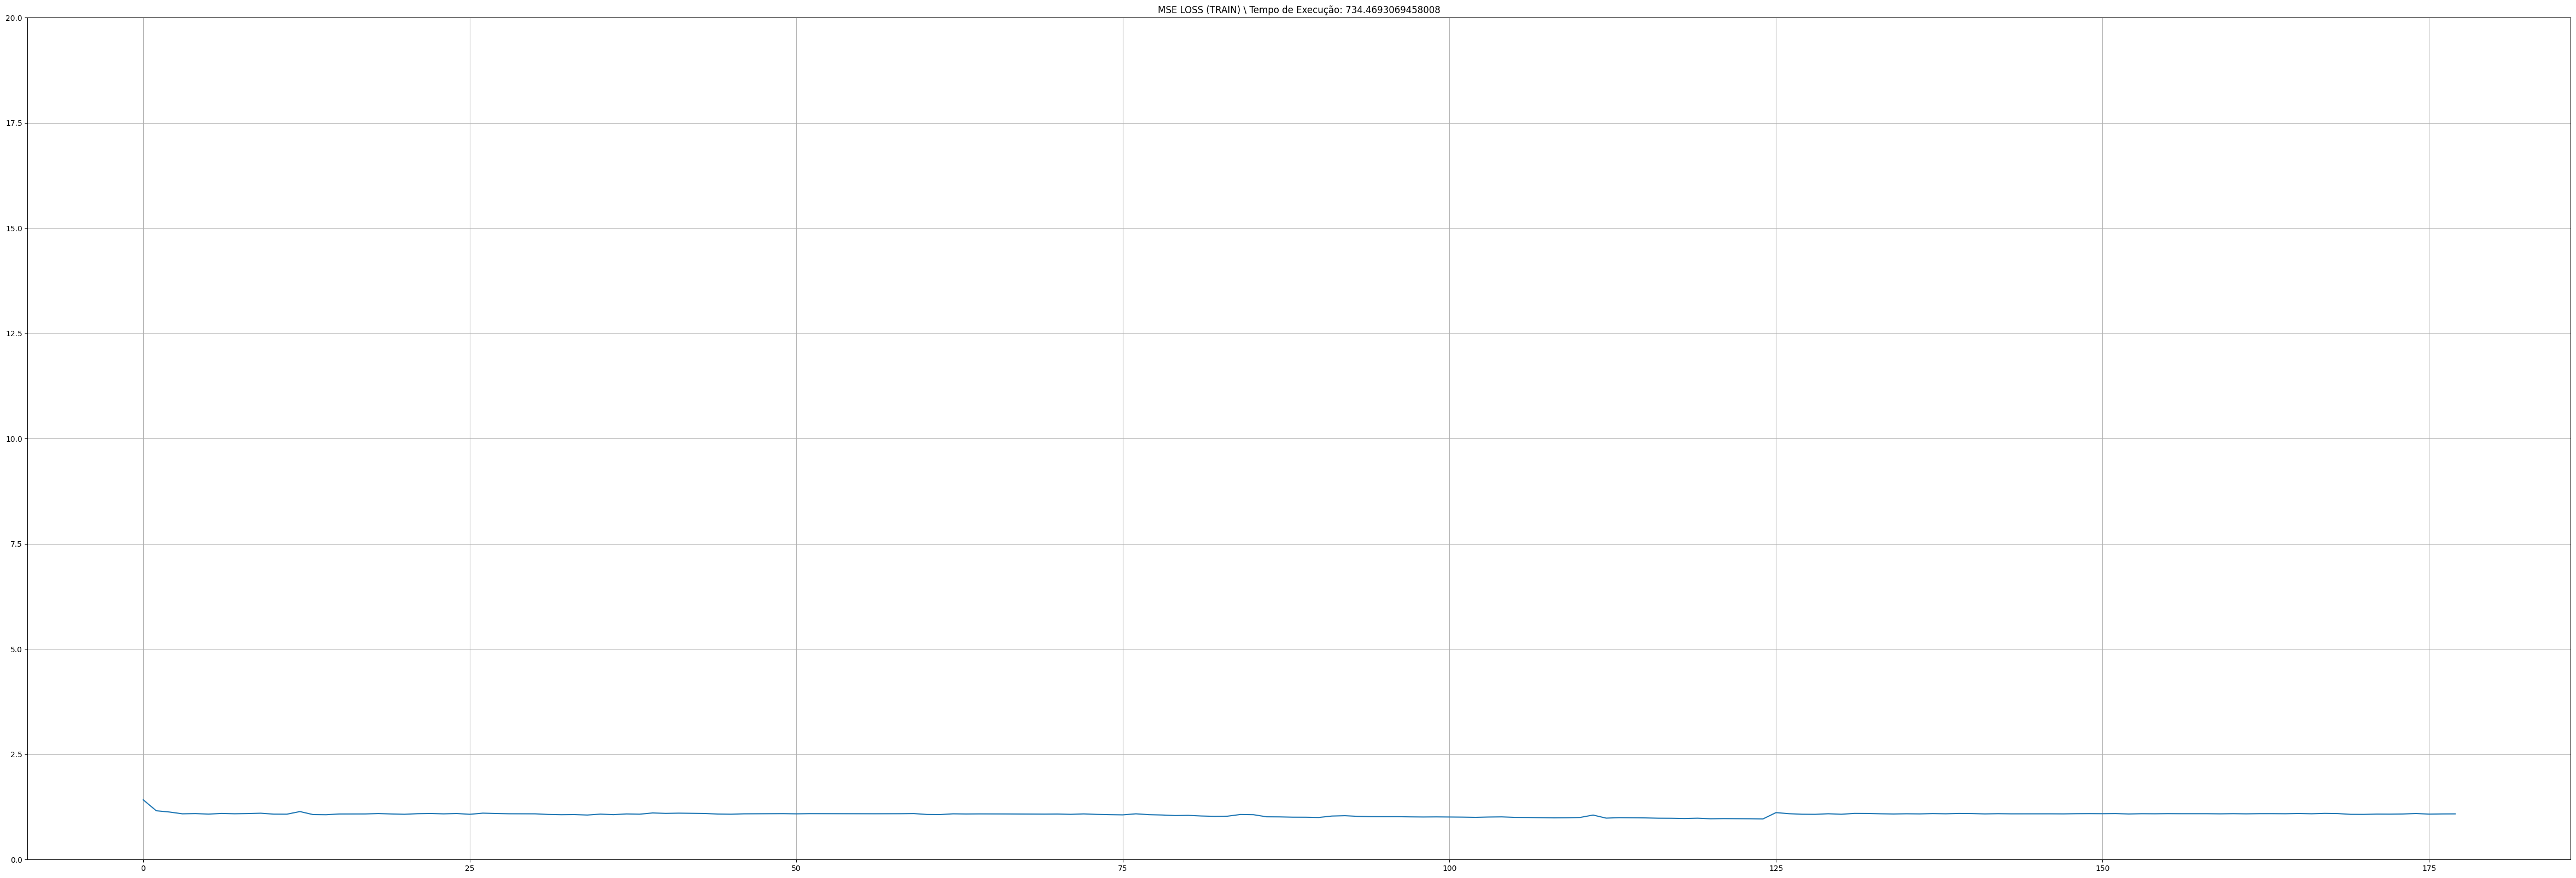

OK


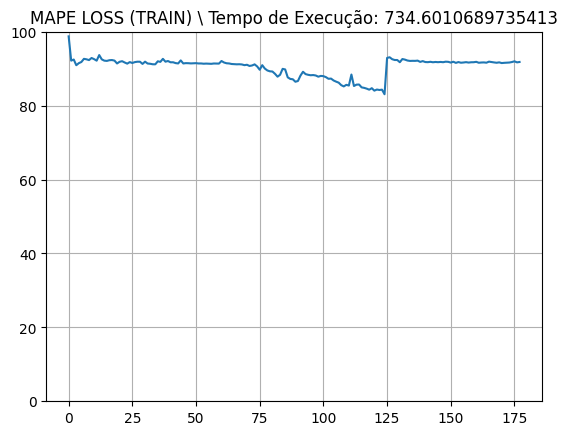

OK


In [ ]:
plt.figure(figsize=(60,20))
plt.plot(torch.tensor(train_mse).cpu())
plt.ylim(0,20)
plt.grid(True)
#plt.xticks([10*t for t in range(int(len(train_mse)/10))])
plt.title("MSE LOSS (TRAIN) \\ Tempo de Execução: "+str(time.time()-tempo_inicio))
#.savefig(path+r"\\MSE_LOSS_TRAIN.svg", format="svg")
plt.show()
print("OK")
#plt.figure(figsize=(60,20))
plt.plot(100*torch.tensor(train_mae).cpu())
plt.ylim(0,100)
plt.grid(True)
#plt.xticks([10*t for t in range(int(len(train_mae)/10))])
plt.title("MAPE LOSS (TRAIN) \\ Tempo de Execução: "+str(time.time()-tempo_inicio))
#plt.savefig(path+r"\\MAPE_LOSS_TRAIN.svg", format="svg")
plt.show()
print("OK")
hiper_log =" epochs:"+str(epochs)+"\n hidden_dim:"+str(hidden_dim)+"\n patience:"+str(patience)+"\n weight_decay:"+str(weight_decay)+"\n lr:"+str(lr)+"\n Loss:"+str(loss_fn)+"\n topology:"+topology


torch.save(train_mse,path+r"\train_mse.pt")
torch.save(train_mae,path+r"\train_mae.pt")

torch.save(val_mse,path+r"\val_mse.pt")
torch.save(val_mae,path+r"\val_mae.pt")


with open(path+r"\log_hiper_parametros.txt", "w") as file:
    file.write(hiper_log)
pbar.close()
test_counter += 1

#log_dataset = pd.DataFrame({
##    'lr'                 : lr,
 #   'weight_decay '      : weight_decay,
 #   'epochs'             : epochs,
 #   'period of training' : train_period,
 #   'loss'               : str(loss_fn),
 #   'topology'           : topology,
 #   'feature size'       : X.shape[-1],
 #   'hidden_dim'         : hidden_dim,
 #   'patience'           : patience               
#})

#log_dataset.to_csv(path+"\log_hiperparametros.csv")


torch.save(train_mse,path+r"\train_mse.pt")
torch.save(train_mae,path+r"\train_mae.pt")

torch.save(val_mse,path+r"\val_mse.pt")
torch.save(val_mae,path+r"\val_mae.pt")

In [120]:
path_folder = r"C:\Climate Change Project\Simulations\MULTIVAR_modelsv1\TEST_BATCHS\BATCH_0"

if os.path.exists(path_folder):
    shutil.rmtree(path_folder)
os.mkdir(path_folder)

Training period = 2020-01-01 to 2025-12-31
Iteração 0


torch.Size([150])


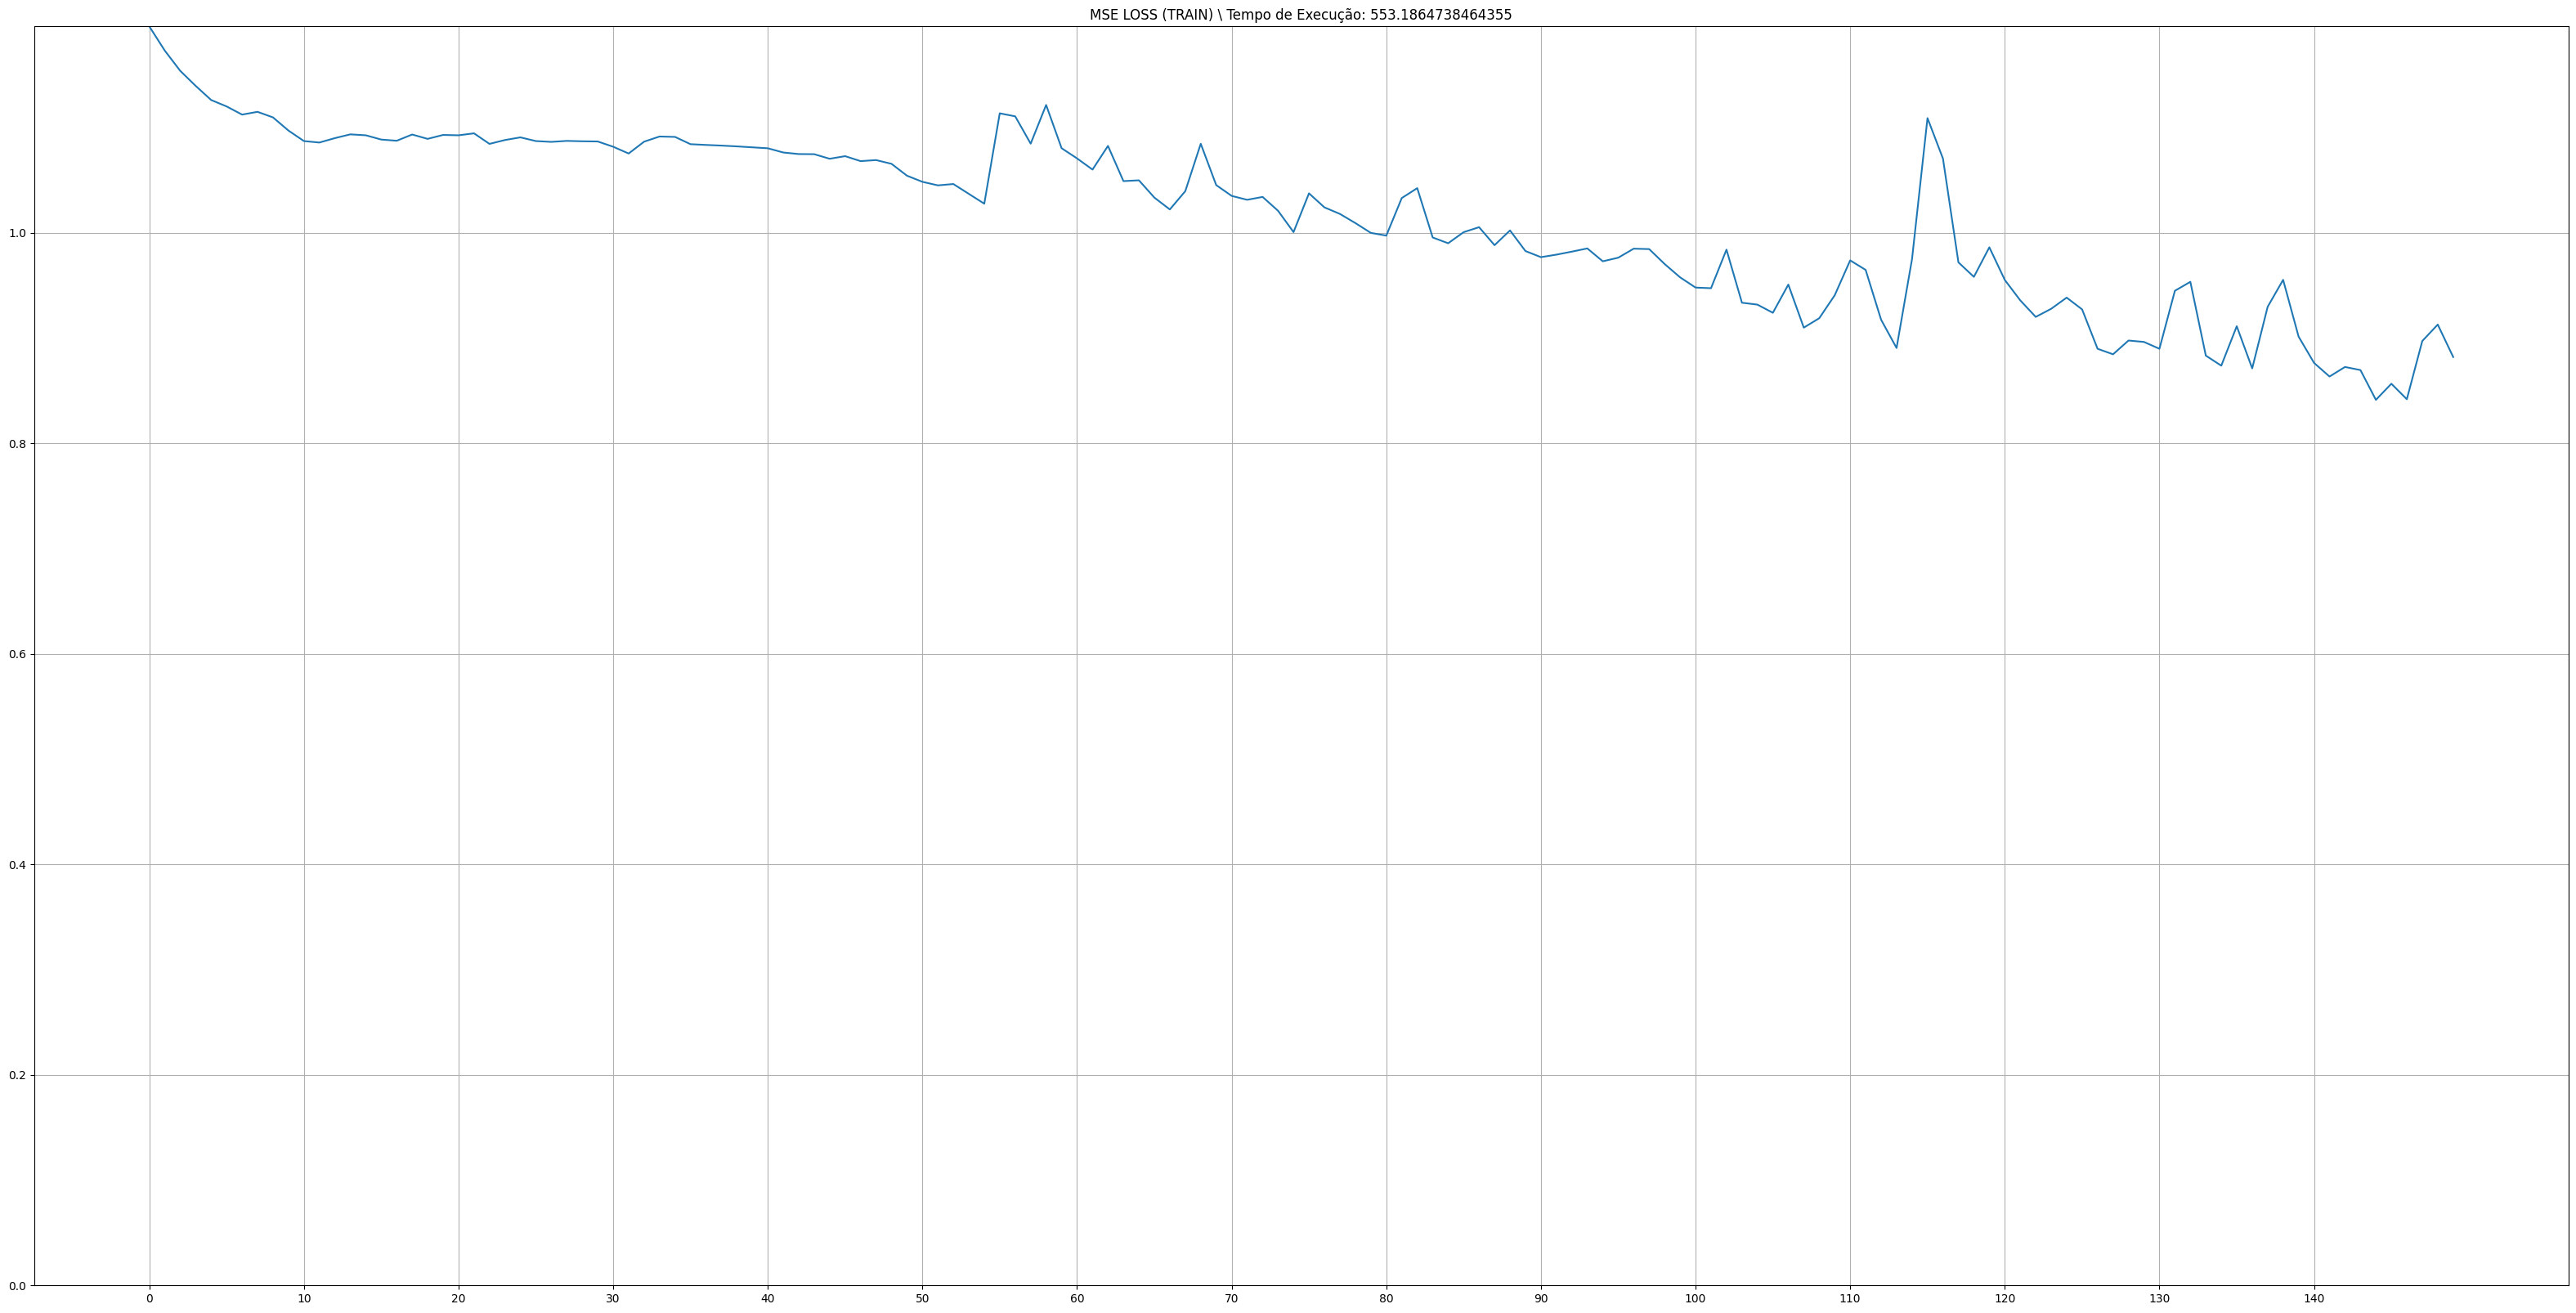

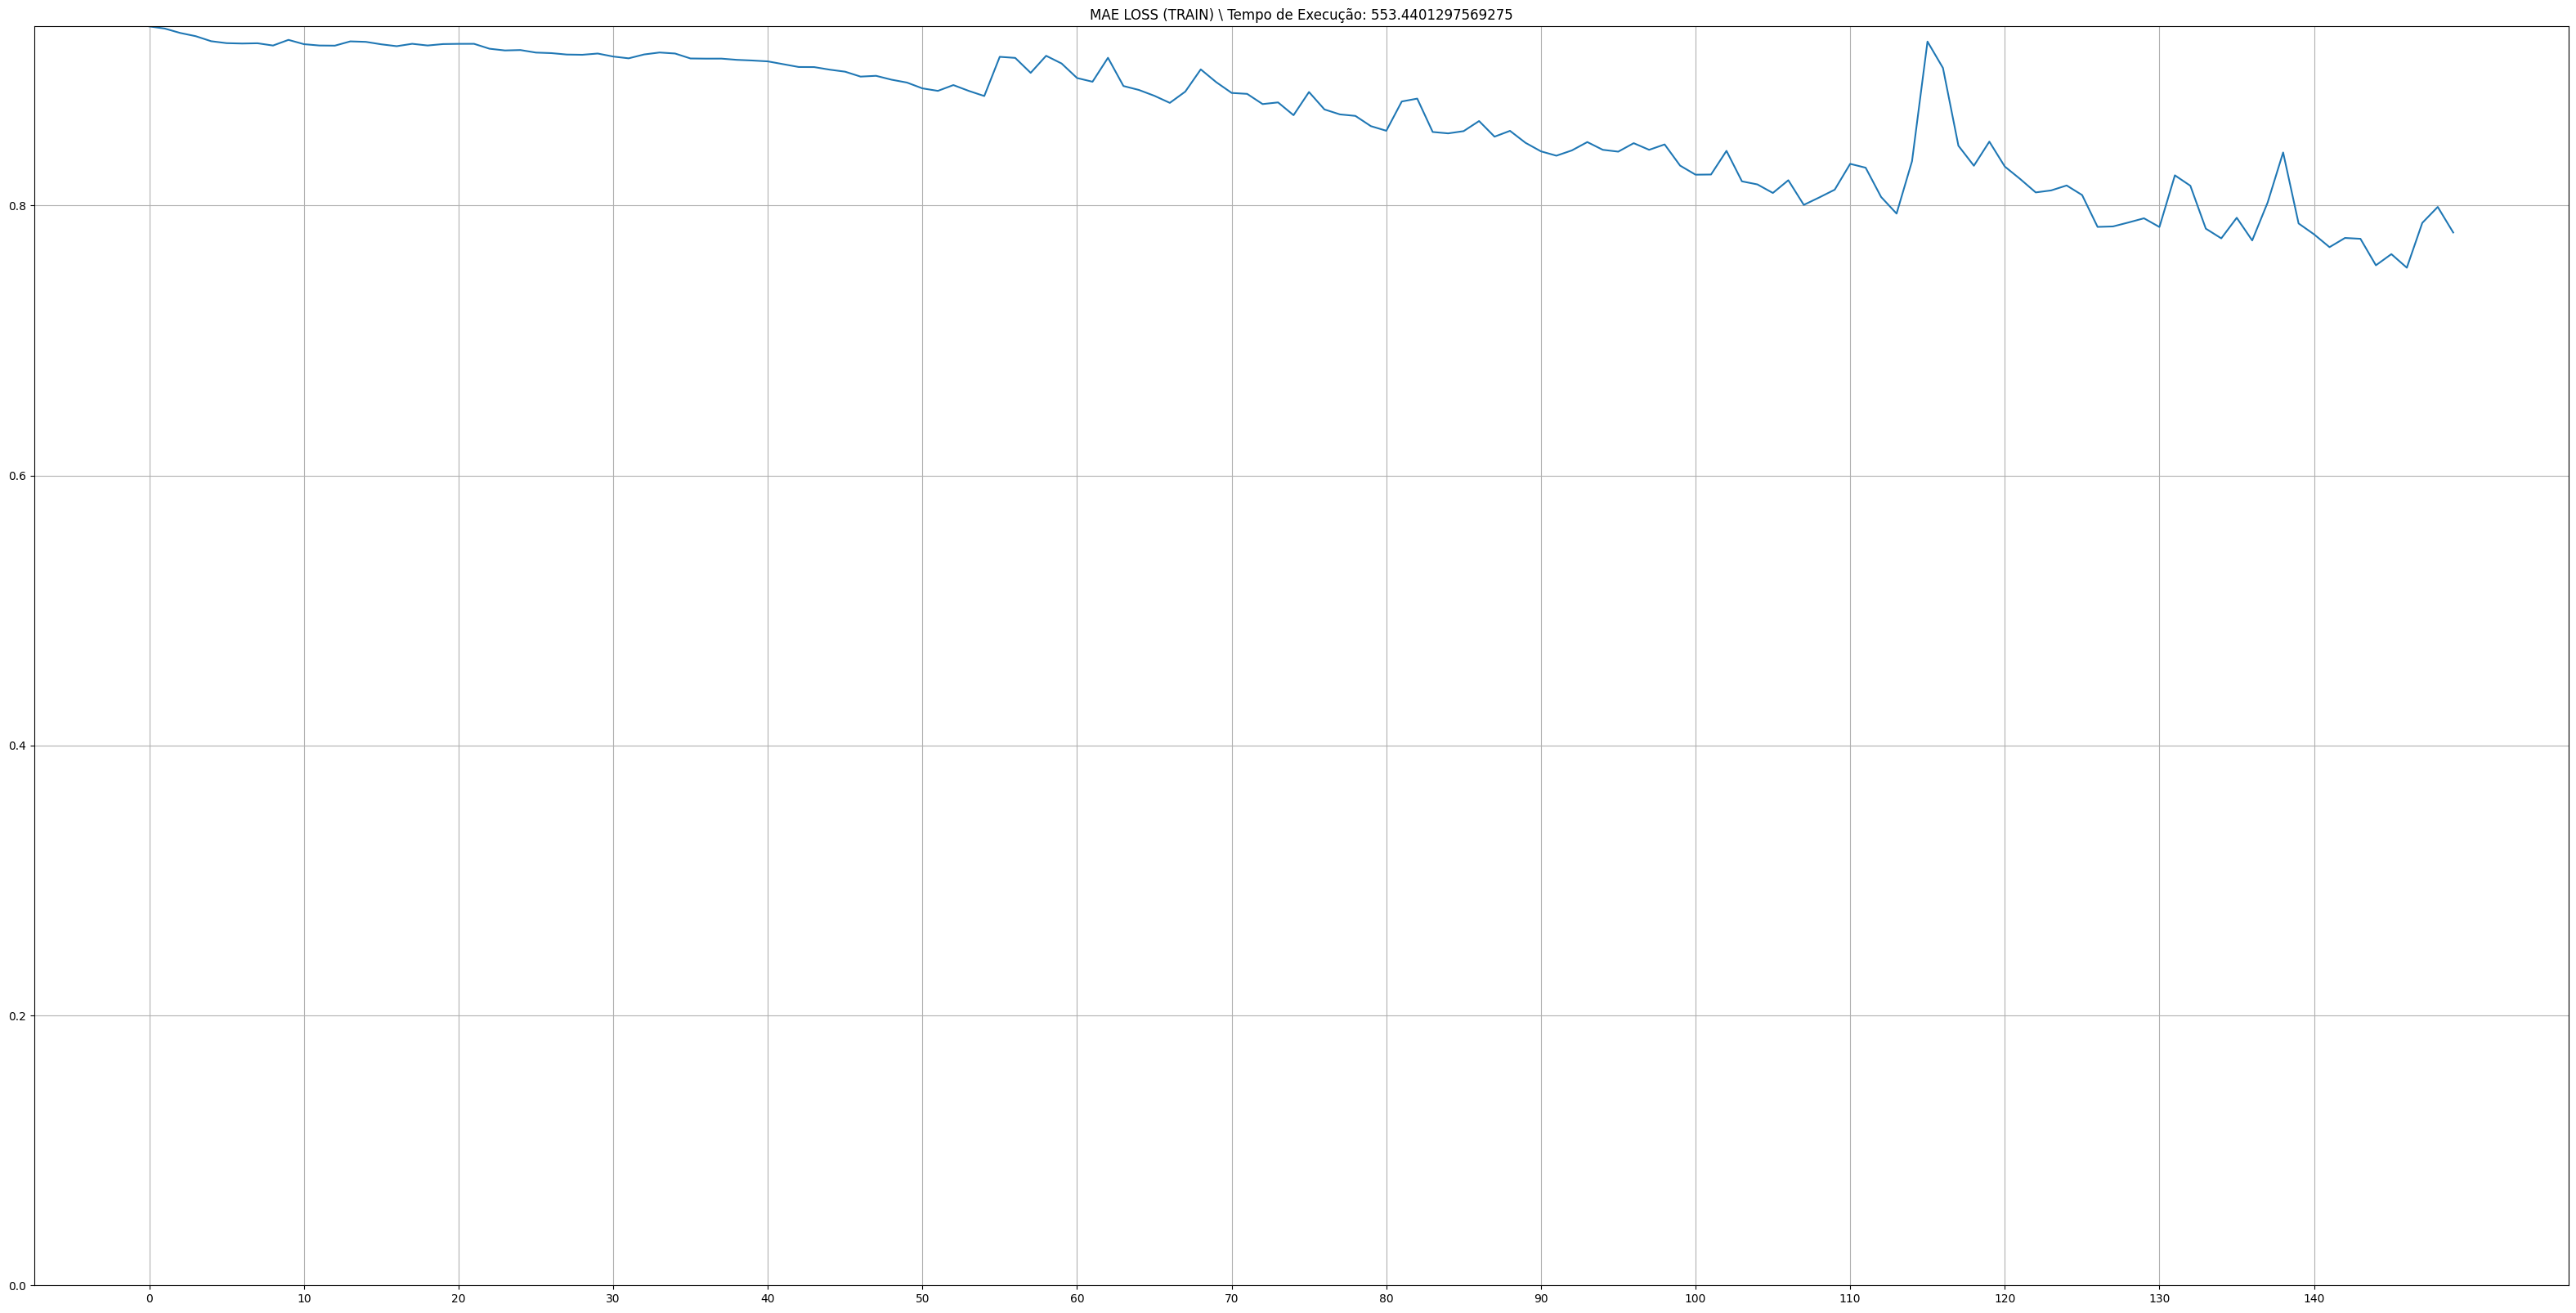

In [ ]:
#ITERAÇÃO DE UM MESMO MODELO

print("Training period = "+str(start_date)+" to "+str(end_date))


topology = 'distance'
N = 62
patience = 150
val_error = 0
epochs = 150
lr = 1e-3
weight_decay = 5e-4
hidden_dim = 8
num_layers = 1

edges = edge_index.to(device) if topology=='distance' else edge_index_knn.to(device)
A = adjacency_matrix(N, edges, edge_weight)

MAE = nn.L1Loss()
MSE = nn.MSELoss()
loss_fn = nn.L1Loss()

T_train = Xs.shape[0]
T_val = val_limit_index
iter_max = 1




for iteration in range(iter_max):
    
    print("Iteração "+str(iteration))
    
    path = path_folder+r"\ITER_"+str(2)

    if os.path.exists(path):
        shutil.rmtree(path)
    os.mkdir(path)



    model = GLSTM(N=N, edge_index=edges, in_channels=14, hidden_size=hidden_dim, num_layers=1, out_channels=1).to(device)
    model.apply(reset_weights)
    optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=weight_decay)

    for p in model.parameters():
        p.requires_grad = True


    best_model = model.state_dict()
    best_val_loss = float('inf')



    all_preds_val, all_val = [], []
    all_preds_train, all_train = [], []
    tempo_inicio = time.time()
    train_loss = []
    val_loss = []
    train_mse = []
    train_mae = []
    val_mse = []
    train_mape = []
    val_mape = []
    loss_fn_train = []
    loss_fn_val = []

    train_r2 = []
    val_r2 = []
    test_r2 = []

    train_rmse = []
    test_rmse = []


    pbar = tqdm.tqdm(total=epochs, leave=False)
    #pbar.close()
    for epoch in range(epochs):
        
        model.train()
        train_loss_counter, train_mse_counter, train_mae_counter, train_r2_counter = 0, 0, 0, 0
        for t in range(T_train):
            X_train = Xs[t].to(device)
            y_train = ys[t,:,0].to(device)
            optimizer.zero_grad()
            y_pred = model(X_train)
            
            loss = loss_fn(y_pred.reshape(N), y_train.reshape(N))
            loss.backward()
            optimizer.step()
            
            all_preds_train.append(y_pred.detach().cpu().reshape(N))
            all_train.append(y_train.cpu().reshape(N))
            
            
            
            train_mse_counter += MSE(y_pred.detach().reshape(N), y_train.reshape(N))
            train_mae_counter += MAE(y_pred.detach().reshape(N), y_train.reshape(N))
            train_r2_counter += r2_score(y_train.reshape(N).cpu(),y_pred.detach().reshape(N).cpu())
        
            train_loss_counter += loss.item()
        
        train_mse_counter /= T_train
        train_loss_counter /=T_train
        train_mae_counter /= T_train
        train_r2_counter /= T_train
        train_loss.append(train_loss_counter)
        train_mse.append(train_mse_counter)
        train_r2.append(train_r2_counter)
        train_mae.append(train_mae_counter)
        model.eval()
        
        val_loss_counter = 0
        
        
        with torch.no_grad():
            for t in range(train_limit_index, val_limit_index):
                X_val = Xs[t].to(device)
                y_val = ys[t,:,0].to(device)
                y_pred = model(X_val)
                loss = loss_fn(y_pred.reshape(N), y_val.reshape(N))
                
                
                
                #val_loss.append(loss.cpu())
                val_mse.append((MSE(y_pred.reshape(N), y_val.reshape(N))))
                val_mape.append(100*MAE(y_pred.reshape(N), y_val.reshape(N)))
                val_r2.append(r2_score(y_val.reshape(N).cpu(), y_pred.reshape(N).cpu()))
                val_loss_count += loss.item()
        pbar.update(1)
        
        #if epoch%10==0 and epoch>0:
            #save_scatter(all_val, all_preds_val, path=path_folder+r"\validation_dispersion\Epoch_"+str(epoch),title="Total validation Dispersion")
        
        val_loss_count /= (Xs.shape[0]-train_limit_index+1)
        
        if val_loss_count<best_val_loss:
            best_val_loss = val_loss_count
            counter = 0
            best_model = model.state_dict()
        else:
            counter+=1
        
        if counter>patience:
            val_loss_count /= Xs.shape[0]-T_train+1
            val_loss.append(val_loss_count)
            model.load_state_dict(best_model)
            print("Early Stopping...")
            break
    hiper_log =" epochs:"+str(epochs)+"\n hidden_dim:"+str(hidden_dim)+"\n patience:"+str(patience)+"\n weight_decay:"+str(weight_decay)+"\n lr:"+str(lr)+"\n Loss:"+str(loss_fn)+"\n topology:"+topology


    print(torch.tensor(train_mse).shape)
    torch.save(train_mse,path+r"\train_mse.pt")
    torch.save(train_mae,path+r"\train_mae.pt")
    torch.save(val_loss,path+r"\val_error.pt")
    torch.save(train_r2,path+r"\train_r2.pt")
    torch.save(val_r2, path+r"\val_r2.pt")


    with open(path+r"\log_hiper_parametros.txt", "w") as file:
        file.write(hiper_log)
    pbar.close()
    

plt.figure(figsize=(40,20))
plt.plot(torch.tensor(train_mse).cpu())
plt.ylim(0,torch.tensor(train_mse).max())
plt.grid(True)
plt.xticks([10*t for t in range(int(len(train_mse)/10))])
plt.title("MSE LOSS (TRAIN) \\ Tempo de Execução: "+str(time.time()-tempo_inicio))
plt.savefig(path+r"\\MSE_LOSS_TRAIN.svg", format="svg")
plt.show()

plt.figure(figsize=(40,20))
plt.plot(torch.tensor(train_mae).cpu())
plt.ylim(0,torch.tensor(train_mae).max())
plt.grid(True)
plt.xticks([10*t for t in range(int(len(train_mae)/10))])
plt.title("MAE LOSS (TRAIN) \\ Tempo de Execução: "+str(time.time()-tempo_inicio))
plt.savefig(path+r"\\MAE_LOSS_TRAIN.svg", format="svg")
plt.show()

"""
plt.figure(figsize=(40,20))
plt.plot(torch.tensor(val_loss).cpu())
plt.ylim(0,torch.tensor(val_loss).max())
plt.grid(True)
plt.xticks([10*t for t in range(int(len(val_loss)/10))])
plt.title("MAPE LOSS (TRAIN) \\ Tempo de Execução: "+str(time.time()-tempo_inicio))
plt.savefig(path+r"\\MAPE_LOSS_TRAIN.svg", format="svg")
plt.show()
"""



test_counter += 1




C:\Users\bruno\AppData\Local\Temp\ipykernel_12860\2449932541.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


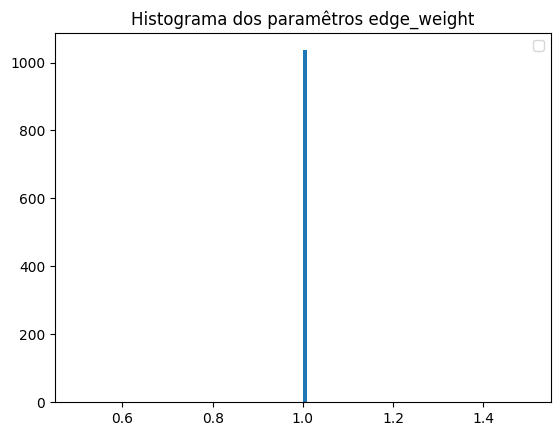

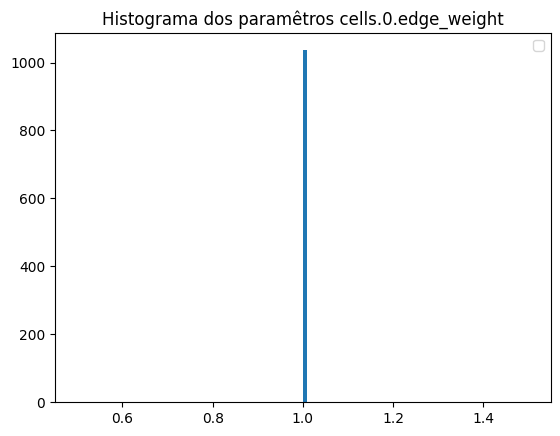

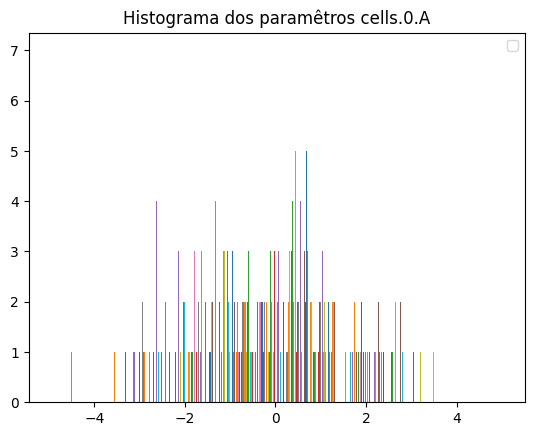

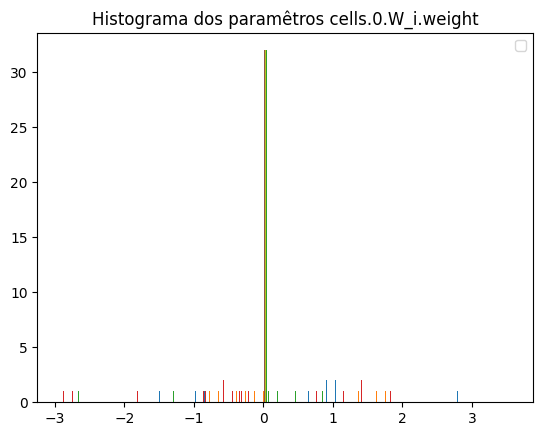

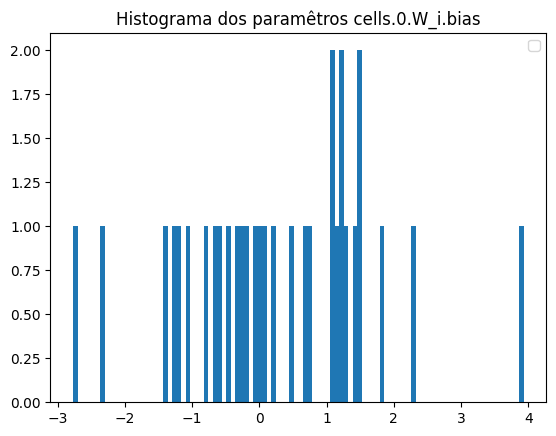

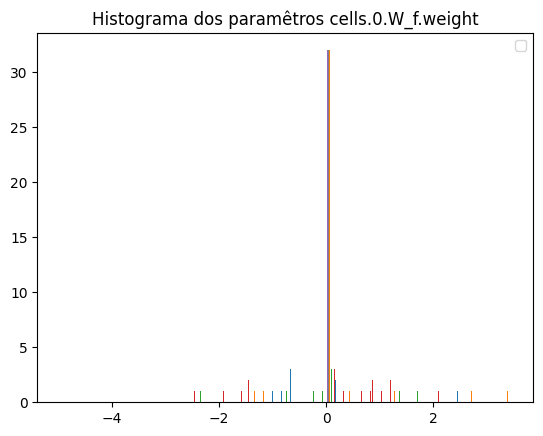

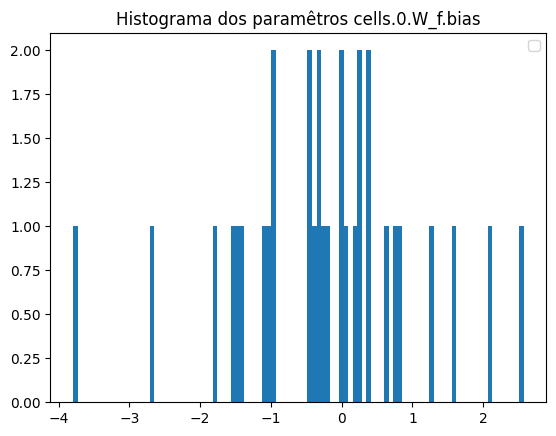

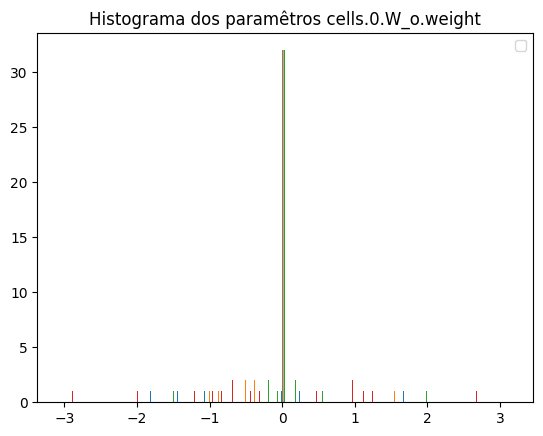

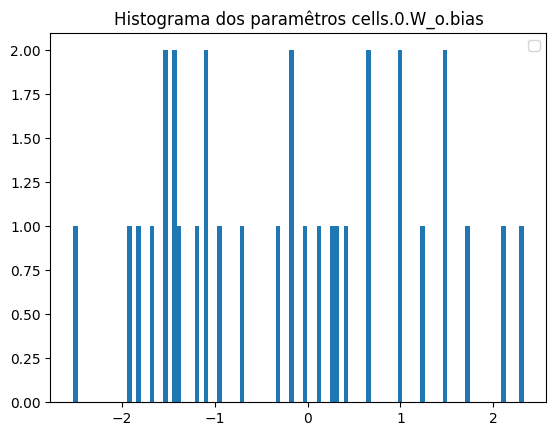

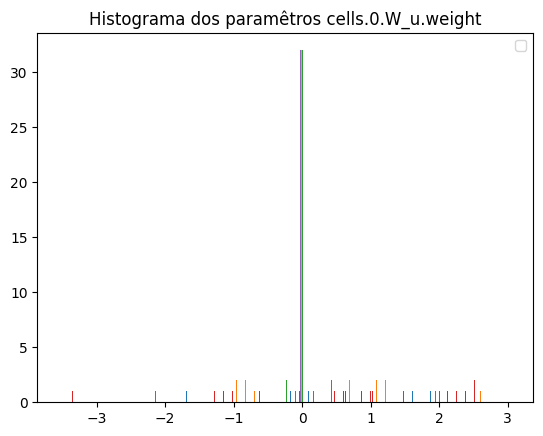

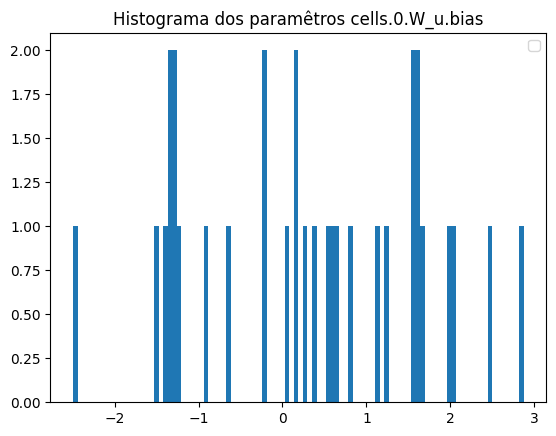

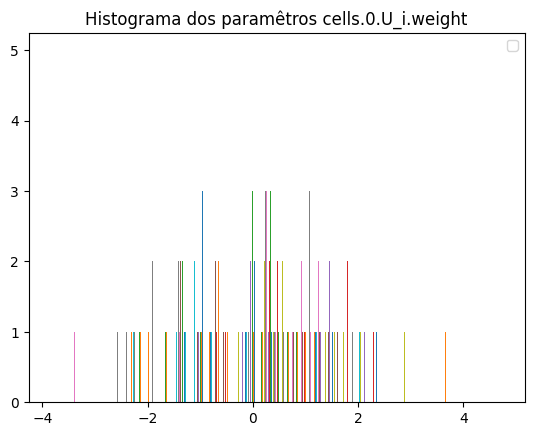

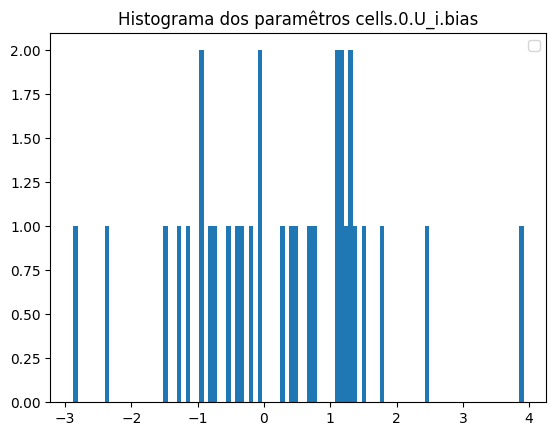

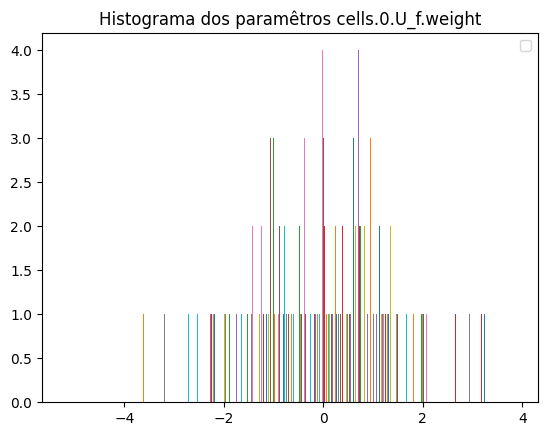

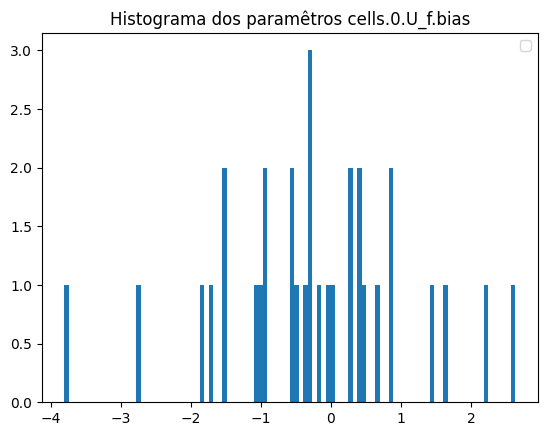

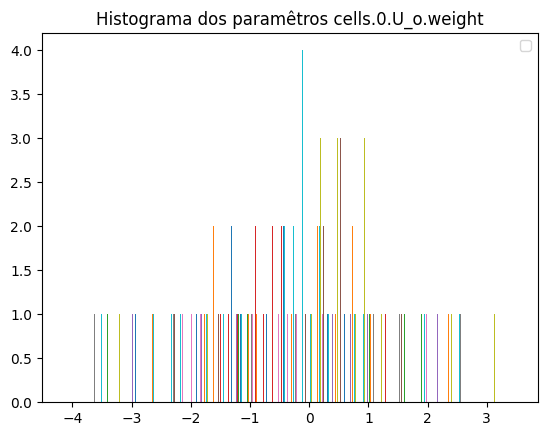

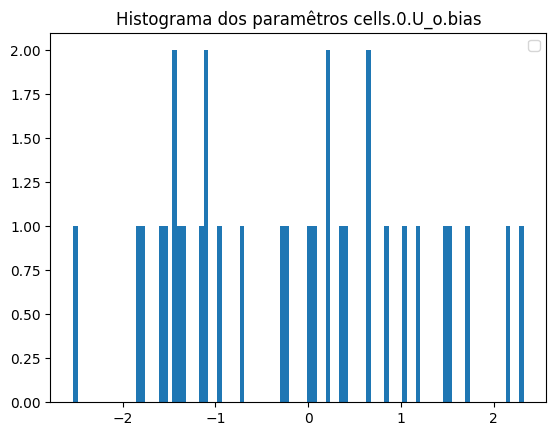

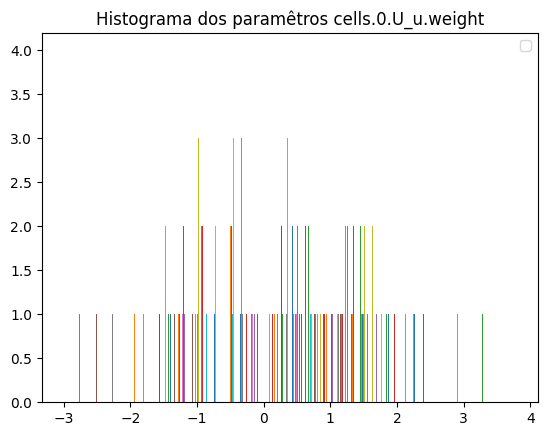

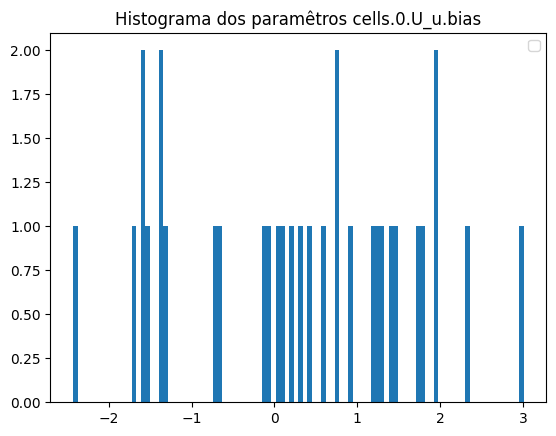

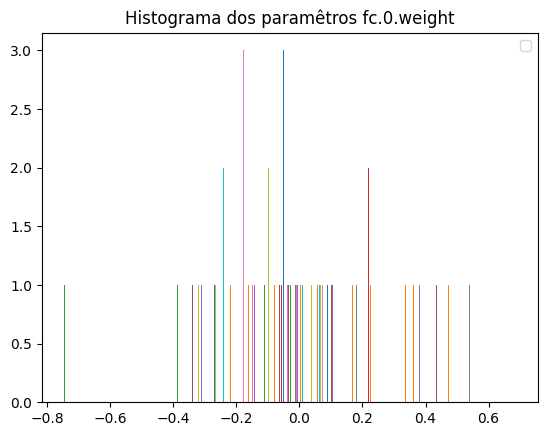

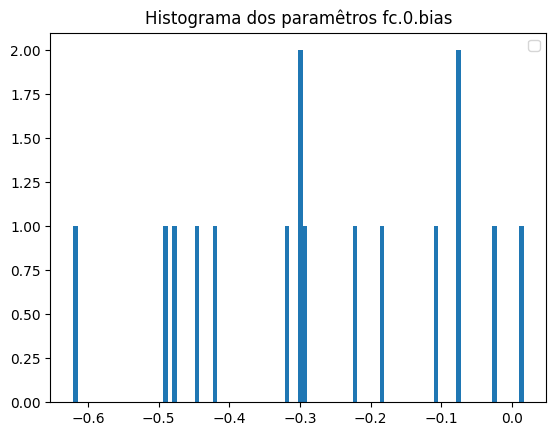

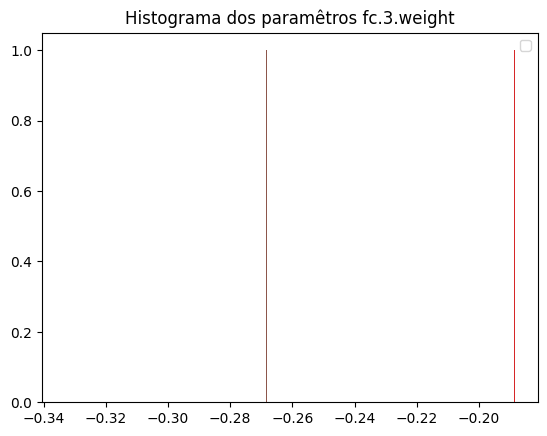

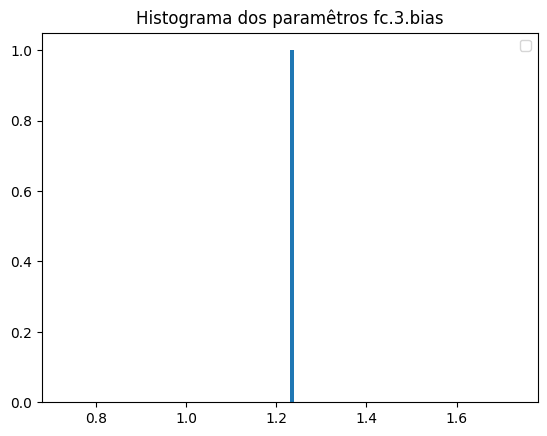

In [ ]:
for name, param in model.named_parameters():
    plt.hist(param.detach().cpu(), bins=100)
    plt.title("Histograma dos paramêtros "+name)
    plt.legend()
    plt.show()

def plot_weights(model, path=None):
    for name, param in model.named_parameters():
        plt.hist(param.detach().cpu())
        plt.title("Weights of "+name)
        plt.legend()
        plt.show()
        if path!=None:
            plt.savefig(path+r"\hist_"+name)

C:\Users\bruno\AppData\Local\Temp\ipykernel_12548\529192100.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


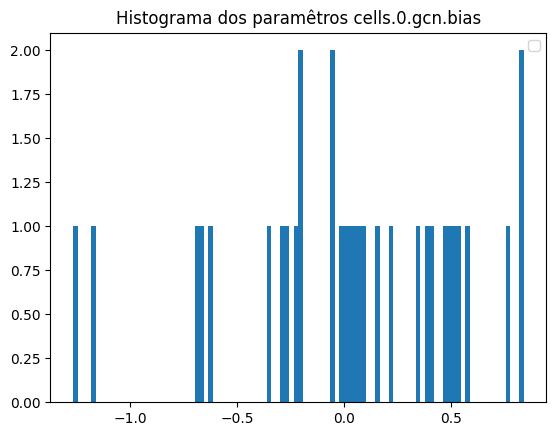

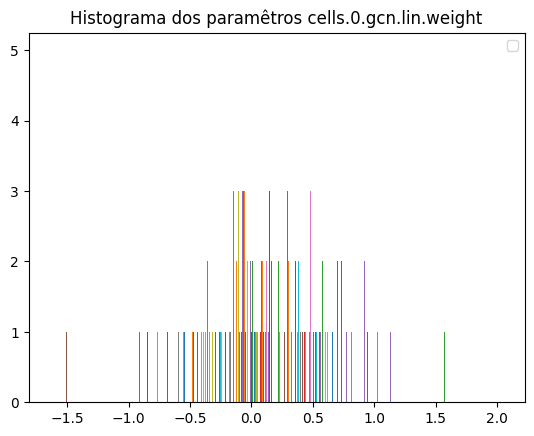

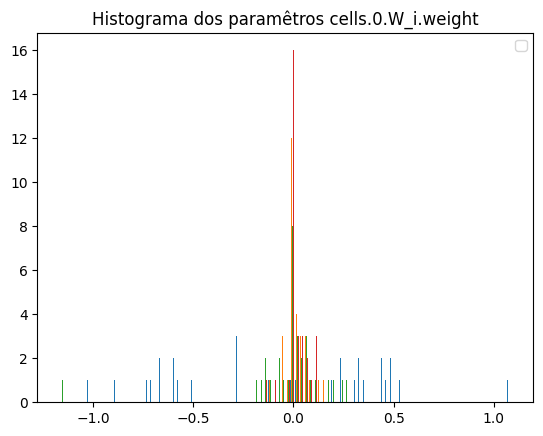

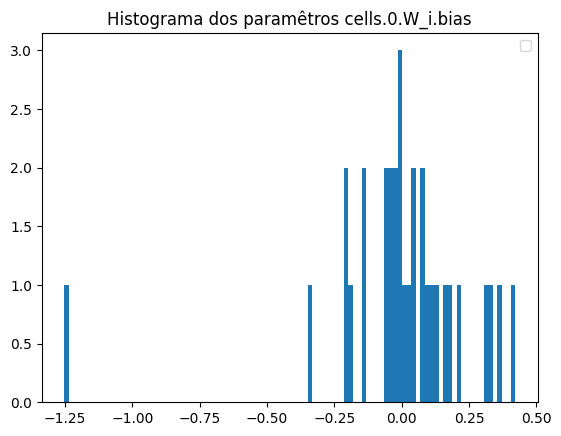

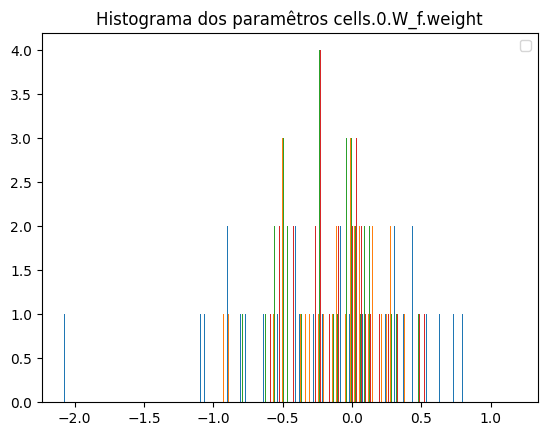

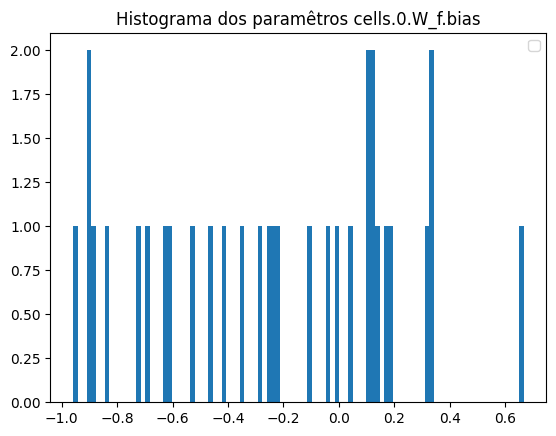

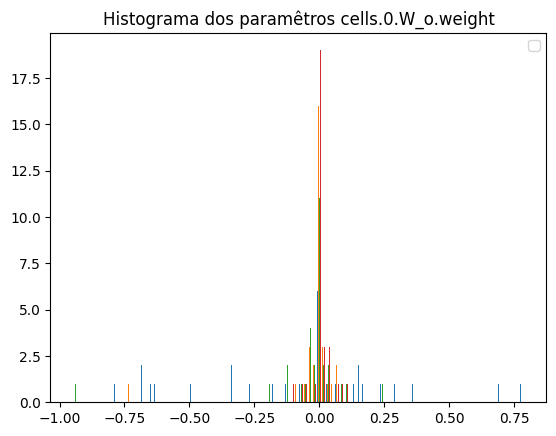

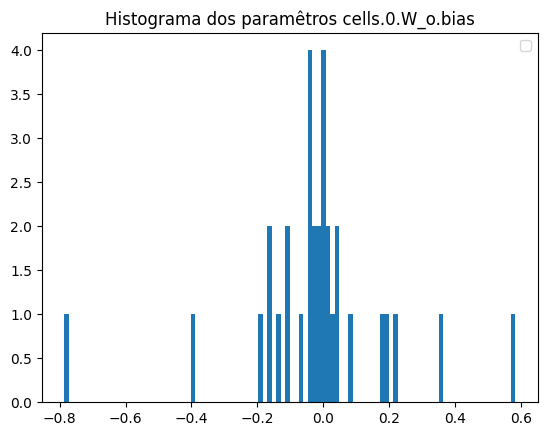

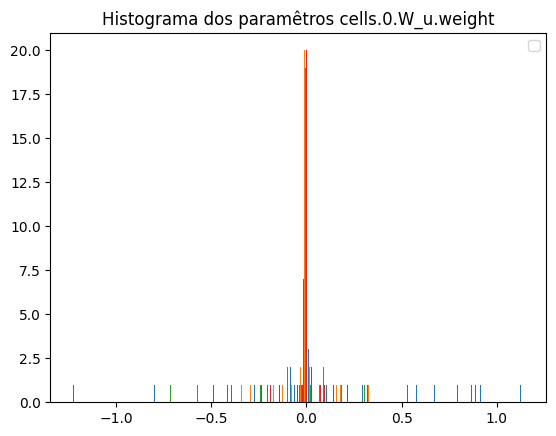

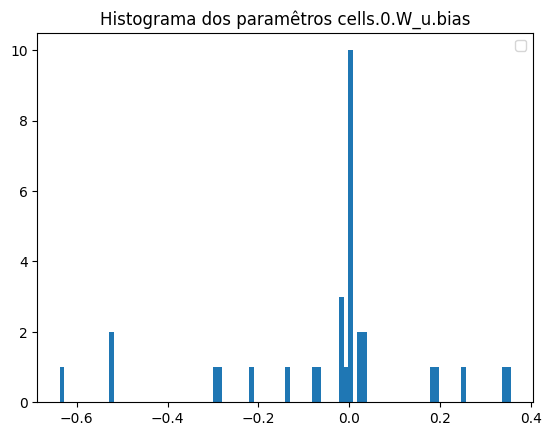

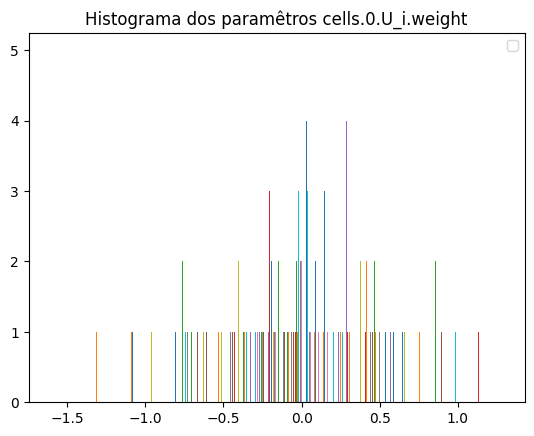

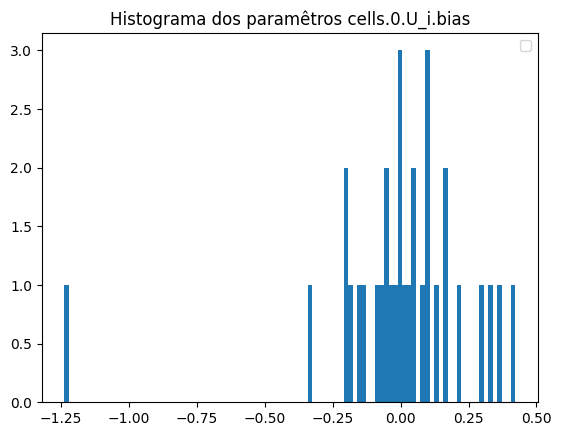

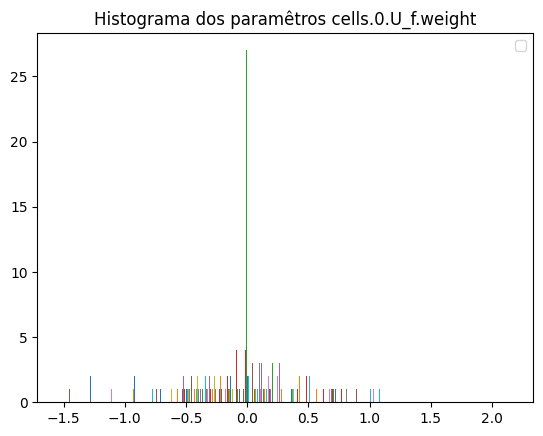

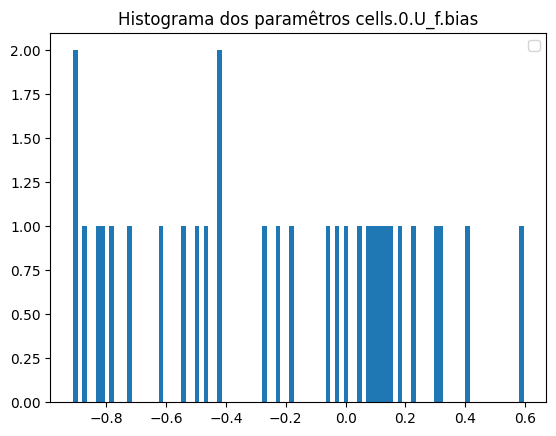

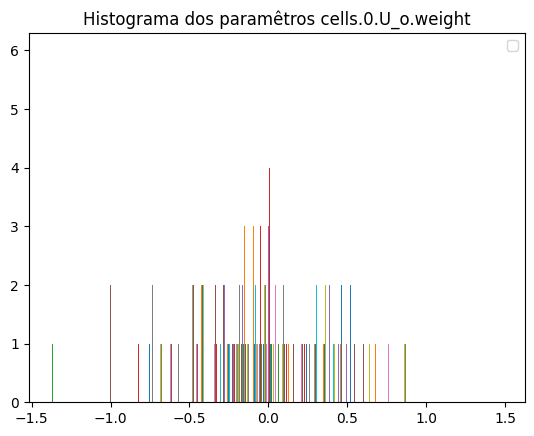

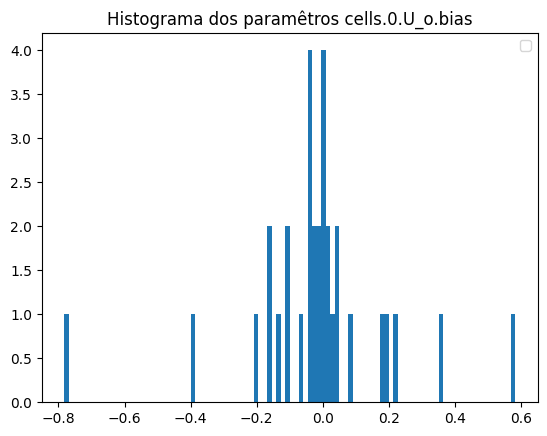

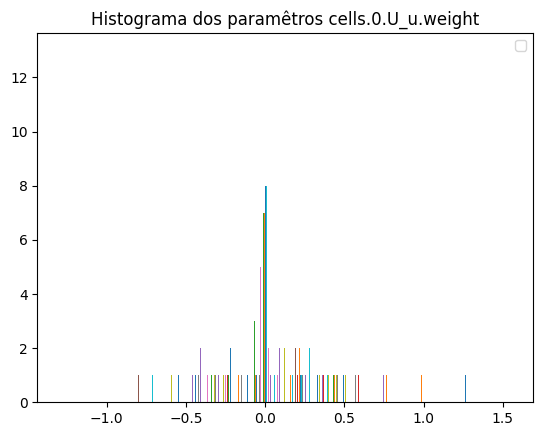

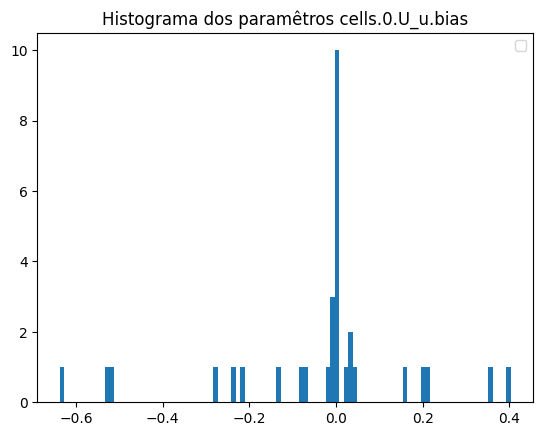

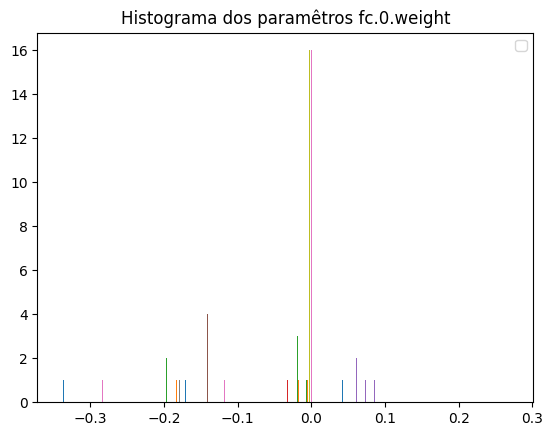

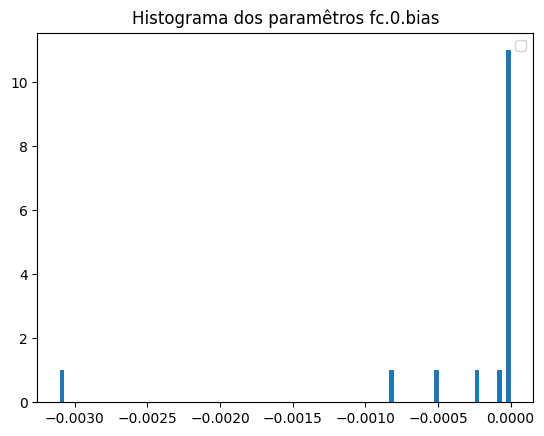

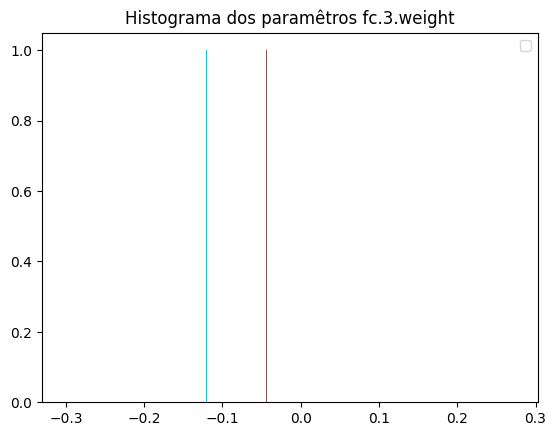

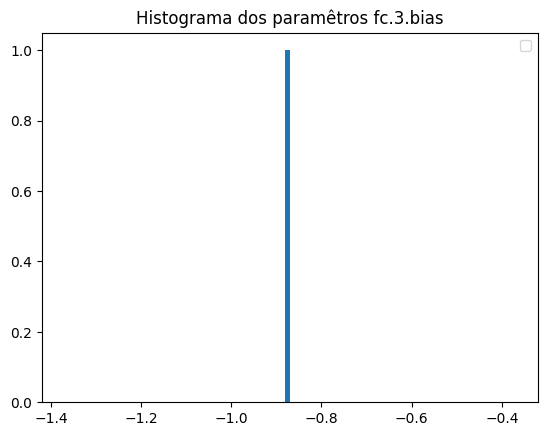

In [ ]:
for name, param in model.named_parameters():
    plt.hist(param.detach().cpu(), bins=100)
    plt.title("Histograma dos paramêtros "+name)
    plt.legend()
    plt.show()

In [ ]:
#IMPLEMENTAR GRID SEARCH PARA HIPER-PARAMETROS
#AUTOMATIZAR ITERAÇÕES DE TESTE DA REDE

param_dict = {
    'lr'         : [1e-2, 1e-3, 1e-4],
    'hidden_dim' : [8, 16, 32, 64],
    'epochs'     : [50, 100, 150, 200]
}

import itertools
def grid_search(param_dict, model, X_train, y_train):
    keys = param_dict.keys()
    values = param_dict.values()
    
    best_score = -float('inf')
    best_params = None
    
    for combination in itertools.product(*values):
        params = dict(zip(keys, combination))
        print(params)


grid_search(param_dict, model=model, X_train=Xs, y_train=ys)

In [ ]:
model.train()
for name, p in model.named_parameters():
    if p.grad is None:
        print(name, "sem gradiente")
    if not p.requires_grad:
        print(name, "requires=False")

chebconv1.bias sem gradiente
chebconv1.lins.0.weight sem gradiente
chebconv1.lins.1.weight sem gradiente
chebconv2.bias sem gradiente
chebconv2.lins.0.weight sem gradiente
chebconv2.lins.1.weight sem gradiente


In [ ]:
def previsao(model, Xs, train_limit, edge_index, stations=estacoes_RS):
    """
    Utiliza o modelo para fazer previsão futura, baseada no dataset Xs com timejumps escolhidos no treino
    """
    period = Xs.shape[1]+1
    edge_index.to(device)
    results = pd.DataFrame({}, index=[day_index(rea, start_date, index=t*period+period) for t in range(train_limit, Xs.shape[0])])
    ground_truth = pd.DataFrame({}, index=[day_index(rea, start_date, index=t*period+period) for t in range(train_limit, Xs.shape[0])])
    
    
    for name in stations.keys():
        results[name] = None
        ground_truth[name] = None
        
        
    for t in range(0,Xs.shape[0]-train_limit):
        X_test = Xs[t].to(device)
        y_pred = model(X_test.to(device),edge_index.to(device)).detach().cpu()
        #CALCULAR INDICE DO X BASEADO NO VALOR DE XS
        #
        results.iloc[t] = y_pred[-1].flatten()
        
        
    return results

test = previsao(model, Xs, train_limit=train_limit_index, edge_index=edge_index)
test.to_csv(r"C:\Climate Change Project\test.csv")




